### Compare CTSM simulation forced with NLDAS data over Gothic, CO, and billy bar's observations
Created by Will Wieder, Jan 2024


In [1]:
%load_ext autoreload
%autoreload 2

from glob import glob
from os.path import join
import dask
from dask_jobqueue import PBSCluster 

import calendar
import cftime

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.pyplot import cm
from cycler import cycler

from distributed import wait

import warnings
warnings.simplefilter("ignore", category=FutureWarning)

%matplotlib inline

---
---
## Read in history files from CLM simulations!
---
---


In [2]:
exp = ['aspen_bgc_52.028_PPT1.25_b_Sturm_2org_zbed_mimics_07d_HIST',
       'aspen_bgc_52.028_PPT1.25_b_Sturm_2org_zbed_mimics_07d_HIST_tauTest12j',
       'aspen_bgc_52.028_PPT1.25_b_Sturm_2org_zbed_mimics_07d_HIST_tauTest12k',
       'aspen_bgc_52.028_PPT1.25_b_Sturm_2org_zbed_mimics_07d_HIST_tauTest14j',
      ]
sim = ['control',
       '12j_winterK',
       '12k_winterK',
       'winterK NoPsc',
      ]
'''

exp = ['aspen_bgc_52.028_PPT1.25_b_Sturm_2org_zbed_century_HIST',
       'aspen_bgc_52.028_PPT1.25_b_Sturm_2org_zbed_mimics_07d_HIST',
       'aspen_bgc_52.028_PPT1.25_b_Sturm_2org_zbed_mimics_07d_HIST_tauTest12j',
      ]
sim = ['Century',
       'MIMICS def',
       'MIMICS winter 12j',
      ]
'''

for i in range(len(sim)):
    f_in = '/glade/derecho/scratch/wwieder/nldas/snodgrass/archive/'+exp[i]+'/lnd/hist/'
    fin = [f_in+exp[i]+'.clm2.h1.1991-01-01-00000.nc']
    #fin = [f_in+exp[i]+'.clm2.h1.1981-01-01-00000.nc',f_in+exp[i]+'.clm2.h1.1991-01-01-00000.nc']
    ds1 = xr.open_mfdataset(fin, decode_times=True).isel(lndgrid=0)
    print('opened '+sim[i])
    if i == 0:
        ds = ds1
    else:
        ds = xr.concat([ds, ds1],dim='sim')

ds = ds.assign_coords({"sim": sim})

print('-- opened files --')

opened control
opened 12j_winterK
opened 12k_winterK
opened winterK NoPsc
-- opened files --


In [3]:
exp[i]

'aspen_bgc_52.028_PPT1.25_b_Sturm_2org_zbed_mimics_07d_HIST_tauTest14j'

#### Convert temperatures to C, Sum Precip fluxes

In [4]:
tempVars = ['TSOI','TBOT','TSA']
for t in tempVars:
    ds[t] = ds[t] - 273.15
    ds[t].attrs['units'] = 'degC'

ds['PPT'] = ds.RAIN + ds.SNOW # mm/s

### Calculate daily data over water years, 
- WY starting here Sept 1, as in billy's data
 - also pull out daily max-min temperatures


In [5]:
ds_daily = ds.resample(time="1D").mean()
ds_daily['TSA_min'] = ds['TSA'].resample(time="1D").min()
ds_daily['TSA_max'] = ds['TSA'].resample(time="1D").max()

spd = 60 * 60 * 24
ds_daily['RAIN'] = ds_daily.RAIN * spd  # mm/d
ds_daily['SNOW'] = ds_daily.RAIN * spd  
ds_daily['PPT'] = ds_daily.PPT * spd 
ds_daily['SR2'] = ds_daily['SR'] + ds_daily.NPP_NUPTAKE
ds_daily['HR_frac'] = ds_daily['HR'] / ds_daily['SR2']

# for wy starting in oct dsWY = ds.shift(time=-273)
shiftWY = -243 #, for OCT = -273
dsWY = ds_daily.copy(deep=True).shift(time=shiftWY)

# for plotting water years
month = [calendar.month_abbr[1:13]]
month_wy = [calendar.month_abbr[9:13]+calendar.month_abbr[1:10]]
dpm = [0, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30]
tick = np.cumsum(dpm)
# Starts in Sept, as with billy's data
dpm_wy = [0,30,31,30,31,31,28,31,30,31,30,31,31]
tick_wy = np.cumsum(dpm_wy)

# Check shift sets WY to Sept 1- Aug 31
dsWY.time.shift(time=shiftWY)

<xarray.DataArray 'time' (time: 3650)> Size: 29kB
array([cftime.DatetimeNoLeap(1991, 9, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1991, 9, 2, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1991, 9, 3, 0, 0, 0, 0, has_year_zero=True), ...,
       nan, nan, nan], dtype=object)
Coordinates:
  * time     (time) object 29kB 1991-01-01 00:00:00 ... 2000-12-31 00:00:00
Attributes:
    long_name:  time
    bounds:     time_bounds

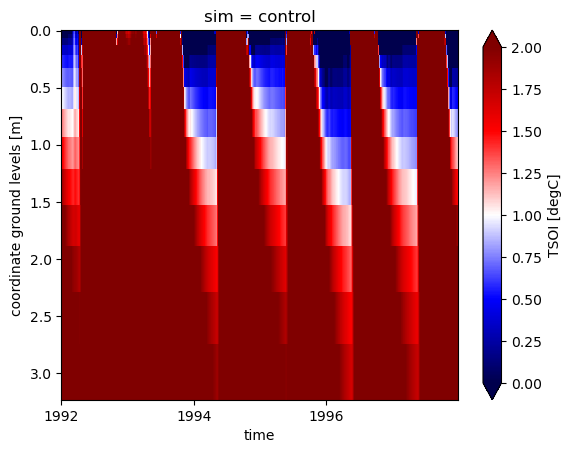

In [6]:
t1, t2 = 1,7
ds_daily.TSOI.isel(sim=0, time=slice((t1*365),(t2*365)),levgrnd=slice(0,14)) \
             .plot(y='levgrnd',vmax=2,vmin=0,cmap='seismic')
plt.gca().invert_yaxis() ;


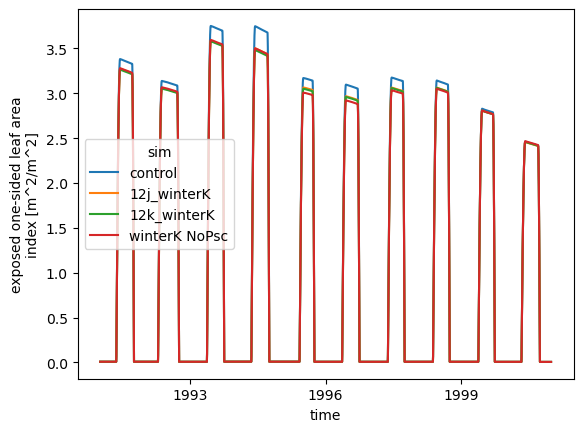

/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/dask/_task_spec.py:741: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


In [6]:
# Quick look at soil tempers 
ds_daily.ELAI.plot(hue='sim') ;

In [7]:
dpm = [0, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30]
mdoy = np.cumsum(dpm)
mdoy

array([  0,  31,  59,  90, 120, 151, 181, 212, 243, 273, 304, 334])

---
Calculate daily climatologies
---


In [8]:
ds_climo = ds_daily.where(ds_daily.time['time.year']<2025).groupby('time.dayofyear').mean()
dsWY_climo = dsWY.where(dsWY.time['time.year']<2025).groupby('time.dayofyear').mean()

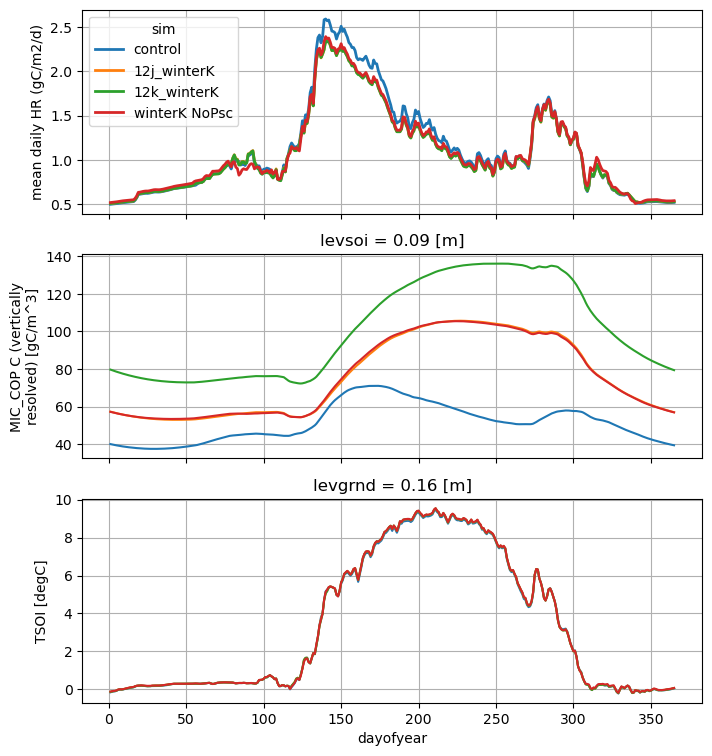

In [9]:
lev = 2
fig, axs = plt.subplots(3, 1, figsize=(8,9),sharex=True)
(ds_climo.HR*spd).plot.line(hue='sim',lw=2,ax=axs[0]) 
axs[0].set_xlabel(None)
axs[0].set_ylabel('mean daily HR (gC/m2/d)')
axs[0].grid()

ds_climo.MIC_COP_C_vr.isel(levsoi=lev).plot(hue='sim',add_legend=False,ax=axs[1]);
#ds_climo.MIC_OLI_C_vr.isel(levsoi=3).plot(hue='sim',add_legend=False,linestyle=':',ax=axs[1]) ;

axs[1].set_xlabel(None)
axs[1].grid()

ds_climo.TSOI.isel(levgrnd=3).plot(hue='sim',add_legend=False,ax=axs[2])
axs[2].grid() ;

In [10]:
ds_climo

<xarray.Dataset> Size: 1MB
Dimensions:       (dayofyear: 365, sim: 4, levdcmp: 25, levgrnd: 25,
                   levsoi: 20, levlak: 10)
Coordinates:
  * levgrnd       (levgrnd) float32 100B 0.01 0.04 0.09 ... 19.48 28.87 42.0
  * levsoi        (levsoi) float32 80B 0.01 0.04 0.09 0.16 ... 5.95 6.94 8.03
  * levlak        (levlak) float32 40B 0.05 0.6 2.1 4.6 ... 25.6 34.33 44.78
  * levdcmp       (levdcmp) float32 100B 0.01 0.04 0.09 ... 19.48 28.87 42.0
  * sim           (sim) <U13 208B 'control' '12j_winterK' ... 'winterK NoPsc'
  * dayofyear     (dayofyear) int64 3kB 1 2 3 4 5 6 ... 360 361 362 363 364 365
Data variables: (12/46)
    mcdate        (dayofyear, sim) float64 12kB dask.array<chunksize=(365, 1), meta=np.ndarray>
    mcsec         (dayofyear, sim) float64 12kB dask.array<chunksize=(365, 1), meta=np.ndarray>
    mdcur         (dayofyear, sim) float64 12kB dask.array<chunksize=(365, 1), meta=np.ndarray>
    mscur         (dayofyear, sim) float64 12kB dask.array<chunksize=(365, 1), meta=np.ndarray>
    nstep         (dayofyear, sim) float64 12kB dask.array<chunksize=(365, 1), meta=np.ndarray>
    AR            (dayofyear, sim) float32 6kB dask.array<chunksize=(365, 1), meta=np.ndarray>
    ...            ...
    landmask      (dayofyear, sim) float64 12kB dask.array<chunksize=(365, 1), meta=np.ndarray>
    nbedrock      (dayofyear, sim) float64 12kB dask.array<chunksize=(365, 1), meta=np.ndarray>
    TSA_min       (dayofyear, sim) float32 6kB dask.array<chunksize=(365, 1), meta=np.ndarray>
    TSA_max       (dayofyear, sim) float32 6kB dask.array<chunksize=(365, 1), meta=np.ndarray>
    SR2           (dayofyear, sim) float32 6kB dask.array<chunksize=(365, 1), meta=np.ndarray>
    HR_frac       (dayofyear, sim) float32 6kB dask.array<chunksize=(365, 1), meta=np.ndarray>
Attributes: (12/39)
    title:                                CLM History file information
    comment:                              NOTE: None of the variables are wei...
    Conventions:                          CF-1.0
    history:                              created on 11/08/25 08:24:16
    source:                               Community Terrestrial Systems Model
    hostname:                             derecho
    ...                                   ...
    ctype_urban_pervious_road:            75
    cft_c3_crop:                          1
    cft_c3_irrigated:                     2
    time_period_freq:                     minute_30
    Time_constant_3Dvars_filename:        ./aspen_bgc_52.028_PPT1.25_b_Sturm_...
    Time_constant_3Dvars:                 ZSOI:DZSOI:WATSAT:SUCSAT:BSW:HKSAT:...

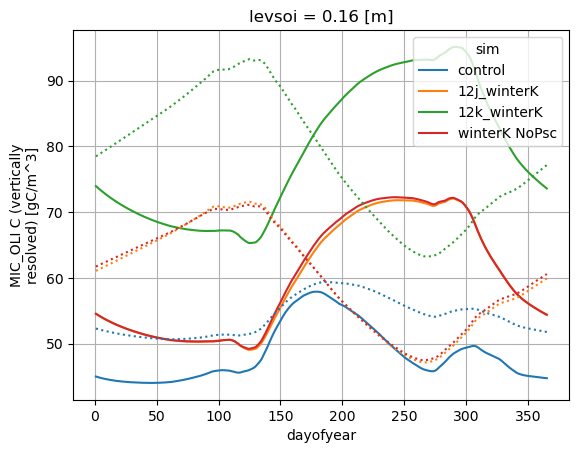

In [11]:
lev = 3
colorlist = ['tab:blue', 'tab:orange','tab:green','tab:red']
#colorlist = ['tab:blue', 'tab:orange','tab:green']
#colorlist = ['tab:blue', 'white','white','tab:red']
#colorlist = ['white','tab:orange','tab:green','tab:red']
cmap = mpl.colors.ListedColormap(colorlist)
custom_cycler = cycler(color=cmap.colors) #or simply color=colorlist
fig = plt.figure()
ax = plt.gca()
    
ax.set_prop_cycle(custom_cycler)
ds_climo.MIC_COP_C_vr.isel(levsoi=lev,sim=[0,1,2,3]).plot(hue='sim',add_legend=True)
ds_climo.MIC_OLI_C_vr.isel(levsoi=lev).plot(hue='sim',linestyle=':',add_legend=False);
ax.grid() ;

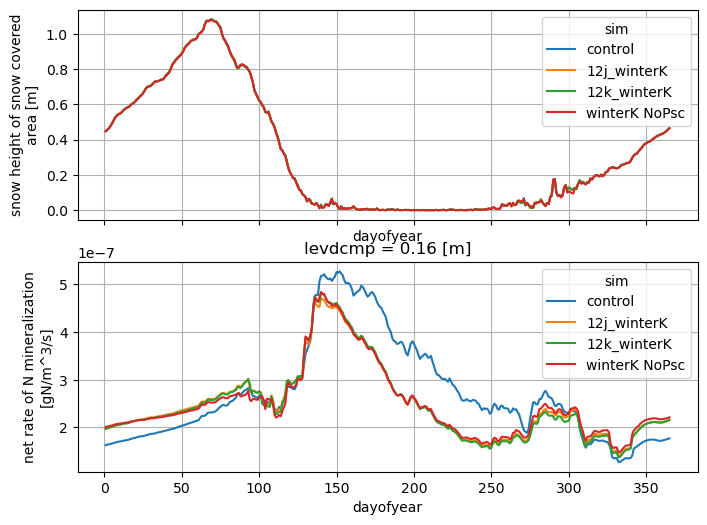

In [12]:
fig, axs = plt.subplots(2, 1, figsize=(8,6),sharex=True)
ds_climo.SNOW_DEPTH.plot(hue='sim', ax=axs[0])
axs[0].grid() 

ds_climo.NET_NMIN_vr.isel(levdcmp=lev).plot(hue='sim',add_legend=True,ax=axs[1]) 
axs[1].grid() ;

In [ ]:
v1, v2 = 'MIC_COP_C_vr', 'MIC_OLI_C_vr'
cmap = mpl.colors.ListedColormap(colorlist)
custom_cycler = cycler(color=cmap.colors) #or simply color=colorlist
fig = plt.figure()
ax = plt.gca()
    
ax.set_prop_cycle(custom_cycler)

ds_climo[v1].isel(levsoi=slice(0,8)).mean('dayofyear').plot(hue='sim',y='levsoi')
ds_climo[v2].isel(levsoi=slice(0,8)).mean('dayofyear').plot(hue='sim',y='levsoi',linestyle=':')

plt.gca().invert_yaxis() ;

## Open up h0 files
- here just for the first year of the simulation for speed
- TODO should add a preprocess function for efficiency

In [21]:
# -- read only these variables from the whole netcdf files
def preprocess_mim(ds):
    variables = ['GPP', 'NPP', 'ELAI', 'NEP', 'AR', 'ER',
                 'NET_NMIN', 'GROSS_NMIN', 'HR','SMINN',
                 'TOTLITC', 'TOTSOMC', 'TOTVEGC', 'TOTMICC',
                 'TOTLITN', 'TOTSOMN', 'TOTVEGN', 'TOTMICN',
                 'SOILC_vr', 'SOILN_vr', 'SMINN_vr', 'HR_vr',
                ]
    litvars = ['LIT_MET_C_vr', 'LIT_STR_C_vr', 'LIT_MET_N_vr', 'LIT_STR_N_vr']
    micvars = ['MIC_COP_C_vr', 'MIC_OLI_C_vr', 'MIC_COP_N_vr', 'MIC_OLI_N_vr']
    somvars = ['SOM_AVL_C_vr', 'SOM_CHEM_C_vr', 'SOM_PHYS_C_vr',
               'SOM_AVL_N_vr', 'SOM_CHEM_N_vr', 'SOM_PHYS_N_vr']
    variables = variables + litvars + micvars + somvars

    ds_new = ds[variables].isel(lndgrid=0)
    ds_new['LITC_vr'] = ds_new.LIT_MET_C_vr + ds_new.LIT_STR_C_vr
    ds_new['LITN_vr'] = ds_new.LIT_MET_N_vr + ds_new.LIT_STR_N_vr
    ds_new['MICC_vr'] = ds_new.MIC_COP_C_vr + ds_new.MIC_OLI_C_vr
    ds_new['MICN_vr'] = ds_new.MIC_COP_N_vr + ds_new.MIC_OLI_N_vr

    return ds_new

# -- read only these variables from the whole netcdf files
def preprocess_cen(ds):
    variables = ['GPP', 'NPP', 'ELAI', 'NEP', 'AR', 'ER',
                 'NET_NMIN', 'GROSS_NMIN', 'HR',
                 'TOTLITC', 'TOTSOMC', 'TOTVEGC',
                 'TOTLITN', 'TOTSOMN', 'TOTVEGN',
                 'SOILC_vr', 'SOILN_vr', 'SMINN', 'SMINN_vr', 'HR_vr',
                ]
    litvars = ['LIT_MET_C_vr', 'LIT_CEL_C_vr', 'LIT_LIG_C_vr',
               'LIT_MET_N_vr', 'LIT_CEL_N_vr', 'LIT_LIG_N_vr']
    somvars = ['SOM_ACT_C_vr', 'SOM_SLO_C_vr', 'SOM_PAS_C_vr',
               'SOM_ACT_N_vr', 'SOM_SLO_N_vr', 'SOM_PAS_N_vr']
    variables = variables + litvars + somvars
    ds_new = ds[variables].isel(lndgrid=0)
    ds_new['LITC_vr'] = ds_new.LIT_MET_C_vr + ds_new.LIT_CEL_C_vr + ds_new.LIT_LIG_C_vr
    ds_new['LITN_vr'] = ds_new.LIT_MET_N_vr + ds_new.LIT_CEL_N_vr + ds_new.LIT_LIG_N_vr
    ds_new['LIT_STR_C_vr'] = ds_new.LIT_CEL_C_vr + ds_new.LIT_LIG_C_vr
    ds_new['LIT_STR_N_vr'] = ds_new.LIT_CEL_N_vr + ds_new.LIT_LIG_N_vr
    ds_new['SOM_PHYS_C_vr'] = ds_new.SOM_PAS_C_vr
    ds_new['SOM_CHEM_C_vr'] = ds_new.SOM_SLO_C_vr
    ds_new['SOM_AVL_C_vr'] = ds_new.SOM_ACT_C_vr
    return ds_new

In [22]:
'''
exp = ['aspen_bgc_52.028_PPT1.25_b_Sturm_2org_zbed_century_HIST',
       'aspen_bgc_52.028_PPT1.25_b_Sturm_2org_zbed_mimics_07d_HIST',
       'aspen_bgc_52.028_PPT1.25_b_Sturm_2org_zbed_mimics_07d_HIST_tauTest12j',
       'aspen_bgc_52.028_PPT1.25_b_Sturm_2org_zbed_mimics_07d_HIST_tauTest12k',
      ]
sim = ['Century',
       'MIMICS def',
       'MIMICS winter 12j',
       'MIMICS winter 12k',
      ]
'''
century = False
for i in range(len(sim)):
    f_in = '/glade/derecho/scratch/wwieder/nldas/snodgrass/archive/'+exp[i]+'/lnd/hist/'
    fin = glob(f_in+exp[i]+'.clm2.h0.2001*.nc')

    if century == True:
        if i == 0:
            ds0 = xr.open_mfdataset(fin, decode_times=True, preprocess=preprocess_cen)
        else:
            dsmon = xr.open_mfdataset(fin, decode_times=True, preprocess=preprocess_mim)
            ds0 = xr.concat([ds0, dsmon],dim='sim')
    else:
        dsmon = xr.open_mfdataset(fin, decode_times=True, preprocess=preprocess_mim)
        if i == 0:
            ds0 = dsmon
        else:
            ds0 = xr.concat([ds0, dsmon],dim='sim')
    print('opened '+sim[i])
        

ds0 = ds0.assign_coords({"sim": sim})

ds0['LITN_vr'] = ds0.LITN_vr.isel(levdcmp=slice(0,20)).rename({'levdcmp':'levsoi'})

print('-- opened files --')

opened control
opened 12j_winterK
opened 12k_winterK
opened winterK NoPsc
-- opened files --


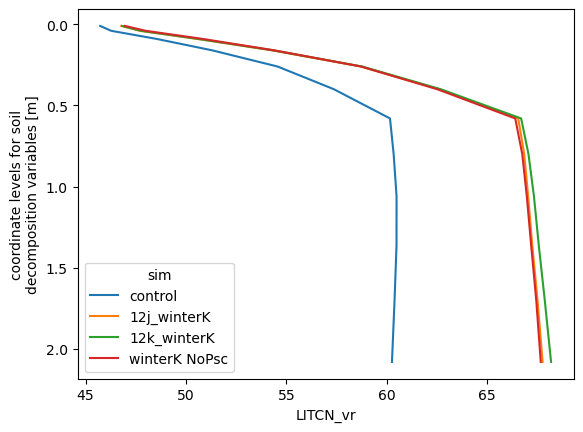

In [23]:
ds0['LITCN_vr'] = ds0.LITC_vr / ds0.LITN_vr
ds0['LITCN_vr'].mean('time').isel(levsoi=slice(0,12)).plot(hue='sim',y='levsoi')
'''
(ds0.MIC_COP_C_vr / ds0.MIC_COP_N_vr.isel(levdcmp=slice(0,20)).rename({'levdcmp':'levsoi'})) \
   .mean('time').isel(levsoi=slice(0,12)).plot(hue='sim',y='levsoi')
(ds0.MIC_OLI_C_vr / ds0.MIC_OLI_N_vr.isel(levdcmp=slice(0,20)).rename({'levdcmp':'levsoi'})) \
   .mean('time').isel(levsoi=slice(0,12)).plot(hue='sim',y='levsoi')
'''
#plt.xscale('log')
plt.gca().invert_yaxis() ;

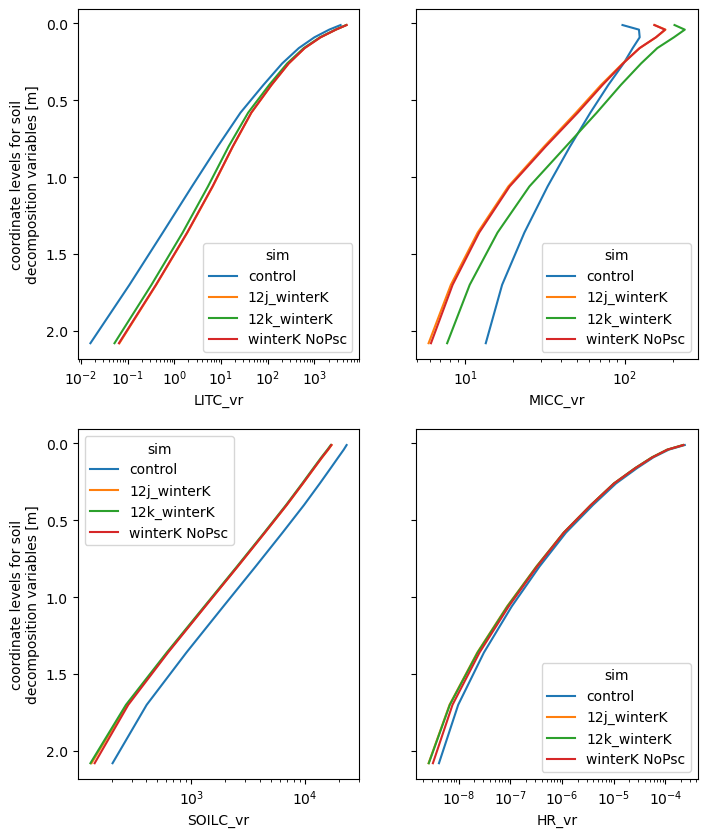

In [24]:
fig, axs = plt.subplots(2, 2, figsize=(8,10),sharey=True)

plot_vars = ['LITC_vr','MICC_vr','SOILC_vr','HR_vr']
i,j = 0,0
for p in range(len(plot_vars)):
    (ds0[plot_vars[p]]).isel(levsoi=slice(0,12)).mean('time').plot(y='levsoi',hue='sim',ax=axs[i,j])
    axs[i,j].set_xscale('log')
    if j == 1:
        axs[i,j].set_ylabel(None)
    j=j+1
    if j == 2:
        i = i+1
        j = 0

plt.gca().invert_yaxis()    


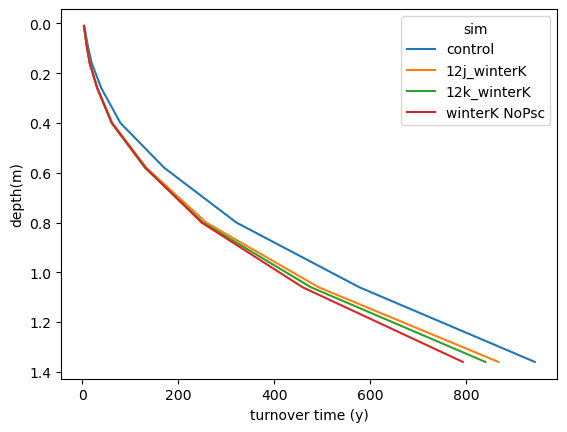

In [25]:
spy = spd * 365
ds0['TOT_SOILC_vr'] = ds0.SOILC_vr + ds0.LITC_vr #+ ds0.MICC_vr
turnover = (ds0.TOT_SOILC_vr.isel(levsoi=slice(0,10)).mean('time') / ds0.HR_vr.isel(levsoi=slice(0,10)).mean('time'))
(turnover/spy).plot(y='levsoi',hue='sim')
#plt.xscale('log')
plt.xlabel('turnover time (y)')
plt.ylabel('depth(m)')
plt.gca().invert_yaxis() ;

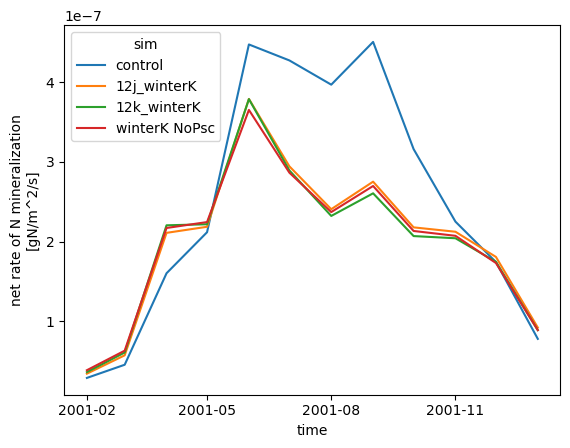

In [26]:
ds0.NET_NMIN.plot(hue='sim') ;

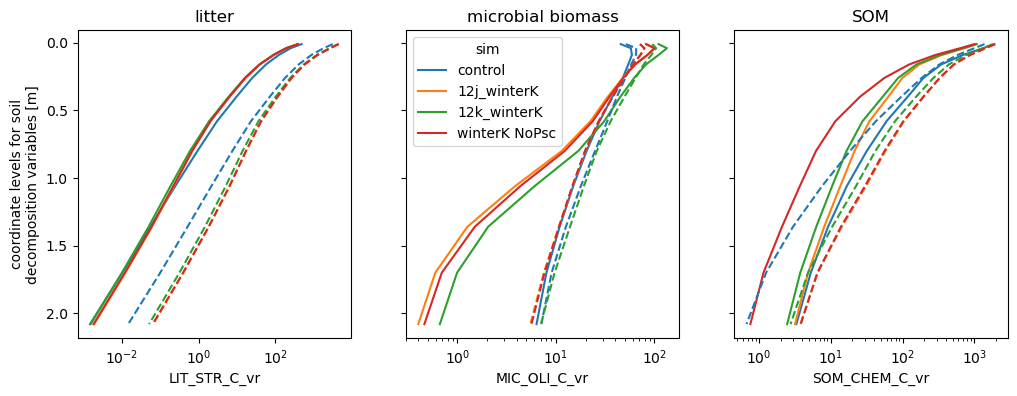

In [51]:
colorlist = ['tab:blue', 'tab:orange','tab:green','tab:red']
cmap = mpl.colors.ListedColormap(colorlist)
custom_cycler = cycler(color=cmap.colors) #or simply color=colorlist

fig, axs = plt.subplots(1, 3, figsize=(12,4), sharey=True)
    
axs[0].set_prop_cycle(custom_cycler)
ds0.LIT_MET_C_vr.mean('time').isel(levsoi=slice(0,12)).plot(
    hue='sim', y='levsoi', add_legend=False, ax=axs[0])
ds0.LIT_STR_C_vr.mean('time').isel(levsoi=slice(0,12)).plot(
    hue='sim', y='levsoi', linestyle='--', add_legend=False, ax=axs[0])
axs[0].set_title('litter')
axs[0].set_xscale('log')

axs[1].set_prop_cycle(custom_cycler)
ds0.MIC_COP_C_vr.mean('time').isel(levsoi=slice(0,12)).plot(
    hue='sim', y='levsoi', ax=axs[1])
ds0.MIC_OLI_C_vr.mean('time').isel(levsoi=slice(0,12)).plot(
    hue='sim', y='levsoi', linestyle='--', add_legend=False, ax=axs[1])
axs[1].set_xscale('log')
axs[1].set_title('microbial biomass')
axs[1].set_ylabel(None)


axs[2].set_prop_cycle(custom_cycler)
ds0.SOM_AVL_C_vr.mean('time').isel(levsoi=slice(0,12)).plot(
    hue='sim', y='levsoi', add_legend=False, ax=axs[2])
ds0.SOM_CHEM_C_vr.mean('time').isel(levsoi=slice(0,12)).plot(
    hue='sim', y='levsoi', linestyle='--', add_legend=False, ax=axs[2])
#ds0.SOM_PHYS_C_vr.mean('time').isel(levsoi=slice(0,12)).plot(
#    hue='sim', y='levsoi', linestyle=':', add_legend=False, ax=axs[2])
axs[2].set_title('SOM')
axs[2].set_ylabel(None)
axs[2].set_xscale('log')

plt.gca().invert_yaxis() 


In [ ]:
levsoi = 6
print(ds0.levsoi.isel(levsoi=levsoi).values)
print('LITm')
print(ds0.LIT_MET_C_vr.mean('time').isel(levsoi=levsoi).values)
print('LITs')
print(ds0.LIT_STR_C_vr.mean('time').isel(levsoi=levsoi).values)
print('MICr')
print(ds0.MIC_COP_C_vr.mean('time').isel(levsoi=levsoi).values)
print('MICk')
print(ds0.MIC_OLI_C_vr.mean('time').isel(levsoi=levsoi).values)
print('SOMa')
print(ds0.SOM_AVL_C_vr.mean('time').isel(levsoi=levsoi).values)
print('SOMc')
print(ds0.SOM_CHEM_C_vr.mean('time').isel(levsoi=levsoi).values)
print('SOMp')
print(ds0.SOM_PHYS_C_vr.mean('time').isel(levsoi=levsoi).values)

In [84]:
(ds0.TOTMICC / ds0.TOTSOMC).mean('time').values

array([       nan, 0.00964474, 0.01558544], dtype=float32)

In [85]:
import math

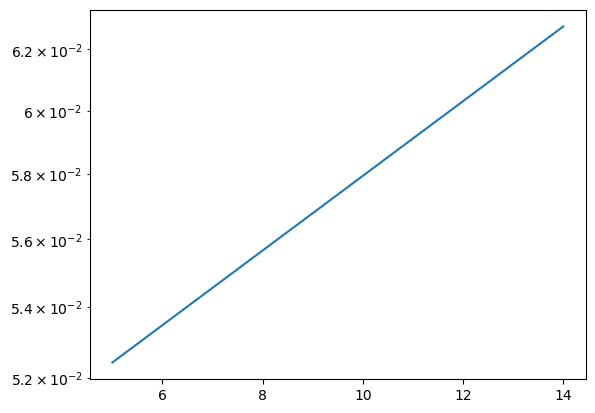

In [70]:
tsoi = np.arange(5,15,1)
k_es = np.empty(len(tsoi))
for t in range(len(tsoi)):
    k_es[t] = math.exp(0.02 * tsoi[t] + 3.19) * 0.001953125
plt.plot(tsoi, k_es) 
plt.yscale('log')


---------------
---------------
old code...
---------------


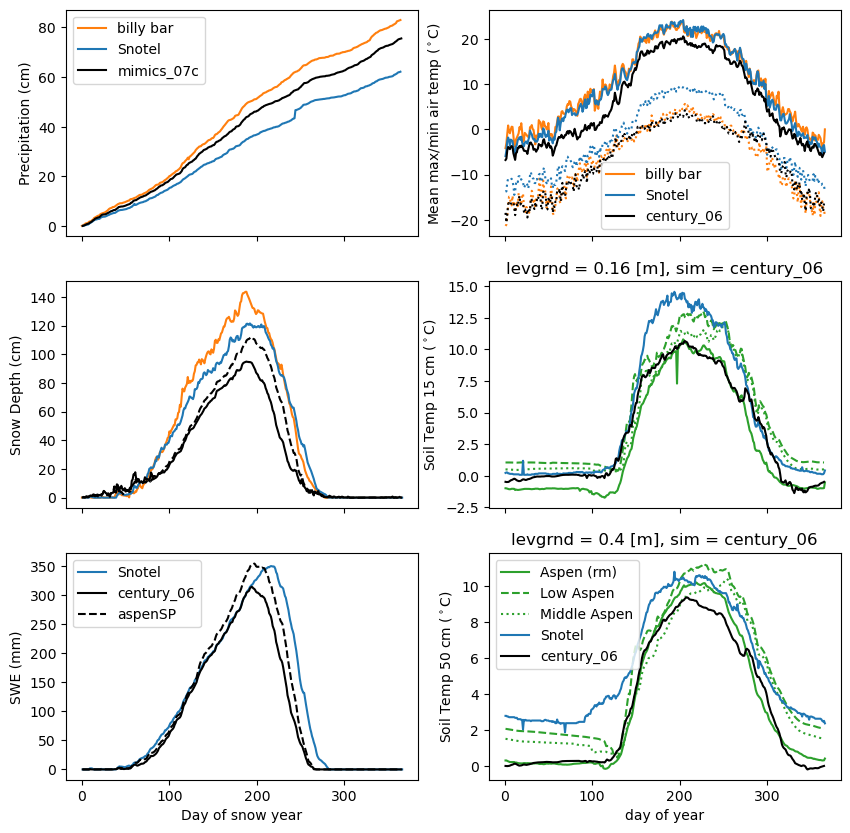

In [52]:
# select simulation and soil levels
# TODO check soil depths for 15 and 50 cm
pSim = 1
l15, l50 = 3, 5

# Plot temperature ranges, snow depth, etc
fig, axs = plt.subplots(3, 2, figsize=(10,10),sharex=True)

## Water and snow, left columm
# Precip
bbWY_climo['sum.ppt.cm'][0:364].plot(label='billy bar',color='tab:orange',ax=axs[0,0])
snotelWY_climo['cumPPT'][0:364].plot(label='Snotel', color='tab:blue',ax=axs[0,0])
(dsWY_climo['PPT'].cumsum('dayofyear')*0.1).isel(sim=pSim).plot(label=sim[(pSim+1)], color='k',ax=axs[0,0])
axs[0,0].set_ylabel('Precipitation (cm)');
axs[0,0].set_title(None);
axs[0,0].legend() ;

# Snow depth
bbWY_climo['snow.on.ground.cm'].plot(label='billy bar',color='tab:orange',ax=axs[1,0])
snotelWY_climo['SNO'].plot(label='Snotel', color='tab:blue',ax=axs[1,0])
(dsWY_climo['SNOW_DEPTH'].isel(sim=pSim)*100).plot(label=sim[pSim], color='k',ax=axs[1,0])
(dsWY_climo['SNOW_DEPTH'].isel(sim=(pSim-1))*100).plot(label=sim[(pSim-1)], color='k',ax=axs[1,0], linestyle='--')
axs[1,0].set_xlabel('Day of snow year');
axs[1,0].set_ylabel('Snow Depth (cm)');
axs[1,0].set_title(None);

# SWE 
snotelWY_climo['SWE'].plot(label='Snotel', color='tab:blue',ax=axs[2,0])
dsWY_climo['H2OSNO'].isel(sim=pSim).plot(label=sim[pSim], color='k',ax=axs[2,0])
dsWY_climo['H2OSNO'].isel(sim=(pSim-1)).plot(label=sim[(pSim-1)], color='k',ax=axs[2,0], linestyle='--')
#dsWY_climo['H2OSNO'].isel(sim=(pSim+1)).plot(label=sim[(pSim+1)], color='k',ax=axs[2,0], linestyle=':')
axs[2,0].set_xlabel('Day of snow year');
axs[2,0].set_ylabel('SWE (mm)');
axs[2,0].legend() ;
axs[2,0].set_title(None);

## Temperature, right colum
# Air temp: max
bb_climo['maximum.temperature'].plot(label='billy bar', color='tab:orange',ax=axs[0,1]) 
snotel_climo.TMAX.plot(label='Snotel', color='tab:blue',ax=axs[0,1])
ds_climo.TSA_max.isel(sim=pSim).plot(label=sim[pSim], color='k',ax=axs[0,1])
axs[0,1].legend() ;

# min
bb_climo['minimum.temperature'].plot(color='tab:orange', linestyle = ':',ax=axs[0,1])
snotel_climo.TMIN.plot(color='tab:blue', linestyle = ':',ax=axs[0,1])
ds_climo.TSA_min.isel(sim=pSim).plot(color='k', linestyle = ':',ax=axs[0,1])
axs[0,1].set_ylabel('Mean max/min air temp ($^\circ$C)');
axs[0,1].set_title(None);

# Soil Temps
obs_soil_climo_rm.unstack().st15.aspen.plot(color='tab:green', label='Reaearch Meadow, Aspen',ax=axs[1,1])
obs_soil_climo.unstack().T_2_Avg.low_aspen.plot(color='tab:green', label='Low Aspen',linestyle = '--',ax=axs[1,1])
obs_soil_climo.unstack().T_2_Avg.middle_aspen.plot(color='tab:green', label='Middle Aspen',linestyle = ':',ax=axs[1,1])
snotel_climo.TSOI_20.plot(color='tab:blue',label='Snotel', ax=axs[1,1])
ds_climo.TSOI.isel(sim=pSim,levgrnd=l15).plot(label=sim[pSim], color='k', ax=axs[1,1]) ;
axs[1,1].set_ylabel('Soil Temp 15 cm ($^\circ$C)');

obs_soil_climo_rm.unstack().st50.aspen.plot(color='tab:green', label='Aspen (rm)', ax=axs[2,1]) 
obs_soil_climo.unstack().T_1_Avg.low_aspen.plot(color='tab:green', label='Low Aspen',linestyle = '--',ax=axs[2,1])
obs_soil_climo.unstack().T_1_Avg.middle_aspen.plot(color='tab:green', label='Middle Aspen',linestyle = ':',ax=axs[2,1])
snotel_climo.TSOI_50.plot(color='tab:blue',label='Snotel', ax=axs[2,1])
ds_climo.TSOI.isel(sim=pSim,levgrnd=l50).plot(label=sim[pSim], color='k', ax=axs[2,1]) ;
axs[2,1].set_xlabel('day of year');
axs[2,1].set_ylabel('Soil Temp 50 cm ($^\circ$C)');
axs[2,1].legend() ;


In [53]:
obs_soil_climo

elevation       date  AirT_C_Avg  Rain_mm_Tot  \
date site                                                            
1    high_conifer       3363.2 2023-01-01   -9.244354     0.001889   
     low_aspen          3023.0 2023-01-01   -7.829292     0.000000   
     middle_aspen       3141.6 2023-01-01   -7.914521     0.000000   
     middle_conifer     3152.1 2023-01-01   -8.218486     0.000000   
2    high_conifer       3363.2 2023-01-02  -10.223160     0.000000   
...                        ...        ...         ...          ...   
364  middle_conifer     3152.1 2022-12-30   -8.312424     0.000000   
365  high_conifer       3363.2 2022-12-31   -6.615292     0.000000   
     low_aspen          3023.0 2022-12-31   -5.222736     0.000826   
     middle_aspen       3141.6 2022-12-31   -5.410056     0.000000   
     middle_conifer     3152.1 2022-12-31   -5.757722     0.000000   

                     SlrFD_W_Avg  VWC_1_Avg  VWC_2_Avg  VWC_3_Avg   T_1_Avg  \
date site                                                                     
1    high_conifer      27.999306   0.082139   0.147958   0.096153  0.498882   
     low_aspen         21.973819   0.094146   0.151333   0.140507  2.057368   
     middle_aspen      33.150576   0.167333   0.246361   0.171076  1.500931   
     middle_conifer    20.295257   0.072722   0.099806   0.082514  1.649979   
2    high_conifer      30.334264   0.081958   0.147500   0.096000  0.491972   
...                          ...        ...        ...        ...       ...   
364  middle_conifer    24.567521   0.072813   0.100528   0.082312  1.681826   
365  high_conifer      13.803611   0.082333   0.148299   0.096000  0.506222   
     low_aspen         20.396708   0.094278   0.151479   0.139715  2.066986   
     middle_aspen      18.498056   0.167653   0.246333   0.170660  1.510097   
     middle_conifer    14.109854   0.072993   0.100021   0.082333  1.664118   

                      T_2_Avg   T_3_Avg  
date site                                
1    high_conifer   -0.108354 -0.339667  
     low_aspen       1.048701  0.499632  
     middle_aspen    0.499618  0.009757  
     middle_conifer  0.268722 -0.244764  
2    high_conifer   -0.108431 -0.339500  
...                       ...       ...  
364  middle_conifer  0.249493 -0.325951  
365  high_conifer   -0.110326 -0.347681  
     low_aspen       1.049590  0.491910  
     middle_aspen    0.499535  0.005472  
     middle_conifer  0.244819 -0.306347  

[1460 rows x 11 columns]

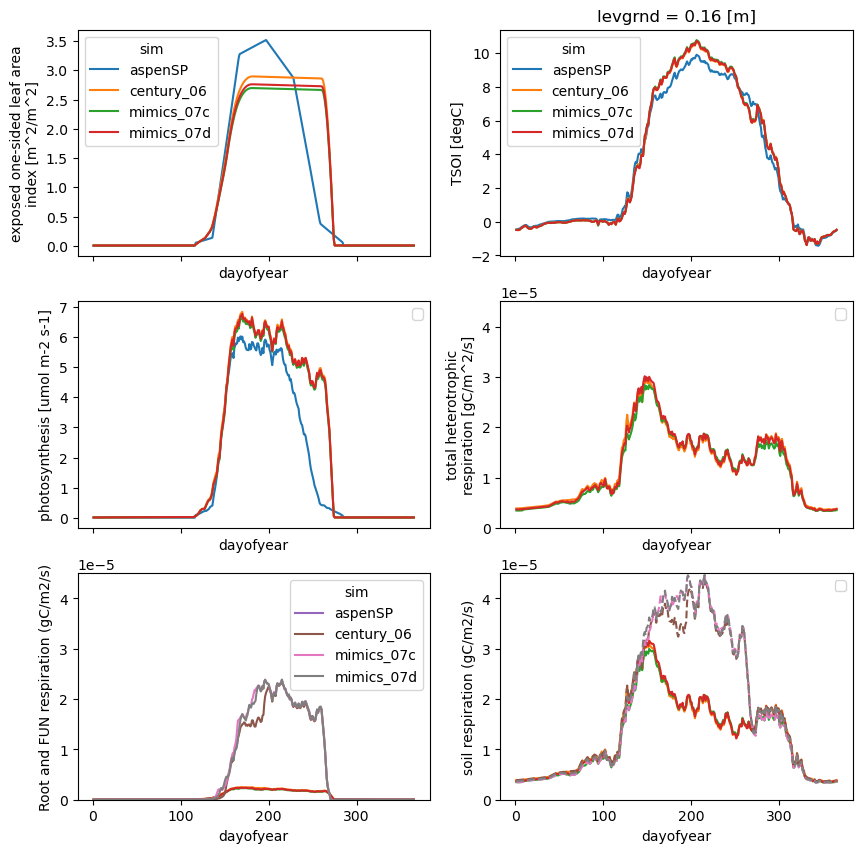

In [54]:
colors = ['tab:blue','tab:orange','tab:green','tab:red']
fig, axs = plt.subplots(3, 2, figsize=(10,10),sharex=True)
ds_climo.ELAI.plot(hue='sim', ax=axs[0,0])

ds_climo.TSOI.isel(levgrnd=l15).plot(hue='sim', ax=axs[0,1]) ;

ds_climo.FPSN.plot(hue='sim', ax=axs[1,0])
axs[1,0].legend([])

ds_climo.HR.plot(hue='sim', ax=axs[1,1])
axs[1,1].legend([])
axs[1,1].set_ylim(0,4.5e-5)

ds_climo.RR.plot(hue='sim', ax=axs[2,0])
ds_climo.NPP_NUPTAKE.plot(hue='sim', ax=axs[2,0])
axs[2,0].set_ylim(0,4.5e-5)
axs[2,0].set_ylabel('Root and FUN respiration (gC/m2/s)') ;

ds_climo.SR.plot(hue='sim', ax=axs[2,1])
(ds_climo.NPP_NUPTAKE+ds_climo.SR).plot(hue='sim', ax=axs[2,1], linestyle='--')#, colors = colors)
axs[2,1].legend([])
axs[2,1].set_ylim(0,4.5e-5) ;
axs[2,1].set_ylabel('soil respiration (gC/m2/s)') ;

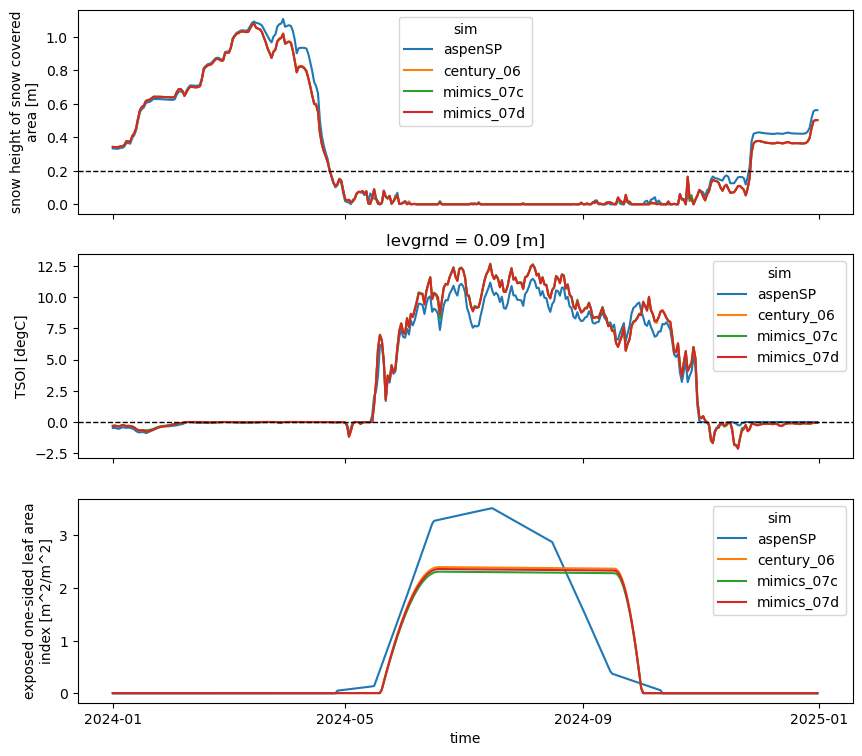

In [55]:
fig, axs = plt.subplots(3, 1, figsize=(10,9),sharex=True)
y = 13
y = 365*y
ds_daily.SNOW_DEPTH.isel(sim=slice(0,None),time=slice(y,y+(1*365))).plot(hue='sim',ax=axs[0])
axs[0].axhline(y=0.2, color='k', linestyle='--', linewidth=1)
axs[0].set_xlabel(None)

ds_daily.TSOI.isel(levgrnd=2,sim=slice(0,None),time=slice(y,y+(1*365))).plot(hue='sim',ax=axs[1]) ;
axs[1].axhline(y=0., color='k', linestyle='--', linewidth=1)
axs[1].set_xlabel(None)

ds_daily.ELAI.isel(sim=slice(0,None),time=slice(y,y+(1*365))).plot(hue='sim',ax=axs[2]) ;

<xarray.Dataset> Size: 1MB
Dimensions:       (dayofyear: 365, sim: 4, levgrnd: 25, levsoi: 20,
                   levdcmp: 26, levlak: 10)
Coordinates:
  * levgrnd       (levgrnd) float32 100B 0.01 0.04 0.09 ... 19.48 28.87 42.0
  * levsoi        (levsoi) float32 80B 0.01 0.04 0.09 0.16 ... 5.95 6.94 8.03
  * levlak        (levlak) float32 40B 0.05 0.6 2.1 4.6 ... 25.6 34.33 44.78
  * levdcmp       (levdcmp) float32 104B 0.01 0.04 0.09 ... 19.48 28.87 42.0
  * sim           (sim) <U10 160B 'aspenSP' 'century_06' ... 'mimics_07d'
  * dayofyear     (dayofyear) int64 3kB 1 2 3 4 5 6 ... 360 361 362 363 364 365
Data variables: (12/48)
    mcdate        (dayofyear, sim) float64 12kB dask.array<chunksize=(365, 1), meta=np.ndarray>
    mcsec         (dayofyear, sim) float64 12kB dask.array<chunksize=(365, 1), meta=np.ndarray>
    mdcur         (dayofyear, sim) float64 12kB dask.array<chunksize=(365, 1), meta=np.ndarray>
    mscur         (dayofyear, sim) float64 12kB dask.array<chunksize=(365, 1), meta=np.ndarray>
    nstep         (dayofyear, sim) float64 12kB dask.array<chunksize=(365, 1), meta=np.ndarray>
    lon           (dayofyear, sim) float32 6kB dask.array<chunksize=(365, 1), meta=np.ndarray>
    ...            ...
    MIC_OLI_C_vr  (dayofyear, sim, levsoi) float32 117kB dask.array<chunksize=(365, 1, 20), meta=np.ndarray>
    PPT           (dayofyear, sim) float64 12kB dask.array<chunksize=(365, 1), meta=np.ndarray>
    TSA_min       (dayofyear, sim) float32 6kB dask.array<chunksize=(365, 1), meta=np.ndarray>
    TSA_max       (dayofyear, sim) float32 6kB dask.array<chunksize=(365, 1), meta=np.ndarray>
    SR2           (dayofyear, sim) float32 6kB dask.array<chunksize=(365, 1), meta=np.ndarray>
    HR_frac       (dayofyear, sim) float32 6kB dask.array<chunksize=(365, 1), meta=np.ndarray>
Attributes: (12/39)
    title:                                CLM History file information
    comment:                              NOTE: None of the variables are wei...
    Conventions:                          CF-1.0
    history:                              created on 07/31/25 18:49:36
    source:                               Community Terrestrial Systems Model
    hostname:                             derecho
    ...                                   ...
    ctype_urban_pervious_road:            75
    cft_c3_crop:                          1
    cft_c3_irrigated:                     2
    time_period_freq:                     minute_30
    Time_constant_3Dvars_filename:        ./aspen_sp52.028_PPT1.25_b_Sturm_2o...
    Time_constant_3Dvars:                 ZSOI:DZSOI:WATSAT:SUCSAT:BSW:HKSAT:...

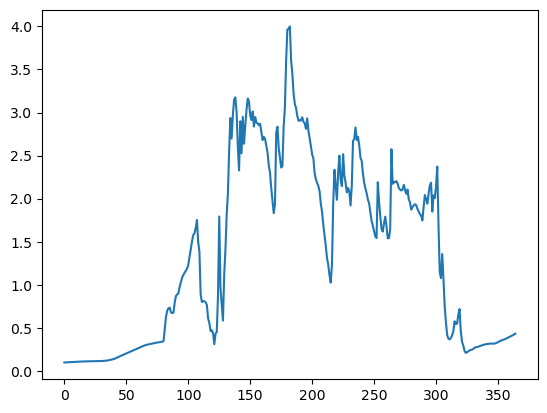

In [56]:
for i in range(13,14):
    d1 = 365*i
    d2 = d1+365
    x = range(365)
    y = (ds_daily.SR*spd).isel(sim=1, time=slice(d1,d2))
    plt.plot(x,y)
ds_climo


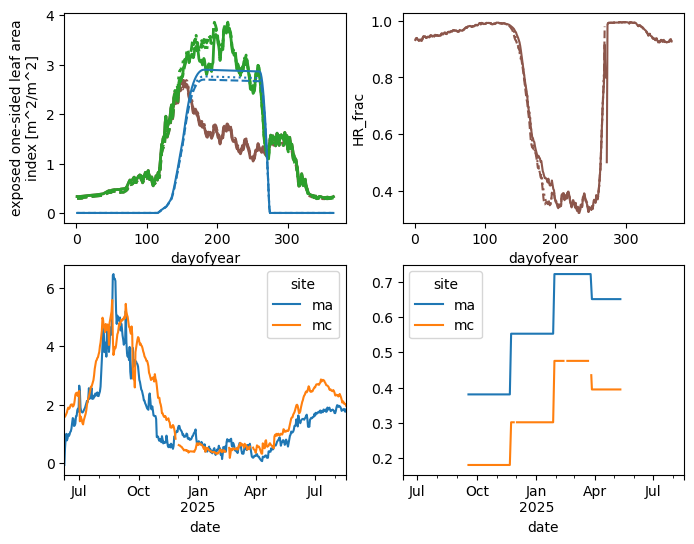

In [58]:
linestyles = ['-', '--', ':'] # Define a list of linestyles

fig, axs = plt.subplots(2, 2, figsize=(8,6))
lines =(ds_climo.SR*spd).isel(sim=slice(1,4)).plot.line(hue='sim', add_legend=False,
                                                        color='tab:brown',lw=2,ax=axs[0,0]) ;
for i, line in enumerate(lines):
    line.set_linestyle(linestyles[i % len(linestyles)]) # Cycle through linestyles if more lines than styles

lines = (ds_climo.SR2*spd).isel(sim=slice(1,4)).plot(hue='sim', add_legend=False,
                                                     color='tab:green',lw=2,ax=axs[0,0]) ;
for i, line in enumerate(lines):
    line.set_linestyle(linestyles[i % len(linestyles)]) # Cycle through linestyles if more lines than styles

lines = (ds_climo.ELAI).isel(sim=slice(1,4)).plot(hue='sim', add_legend=False,
                                                  color='tab:blue',ax=axs[0,0]) 
for i, line in enumerate(lines):
    line.set_linestyle(linestyles[i % len(linestyles)]) ;

lines = ds_climo['HR_frac'].where(ds_climo['HR_frac']<=1).where(ds_climo['HR_frac']>=0).isel(sim=slice(1,4)).plot(hue='sim', add_legend=False,
                                                                                    color='tab:brown',ax=axs[0,1]) 
for i, line in enumerate(lines):
    line.set_linestyle(linestyles[i % len(linestyles)]) ;

snod_flux2.CO2_flux.plot(ax=axs[1,0]) ;
snod_flux2.HR_frac.plot(ax=axs[1,1]) ;


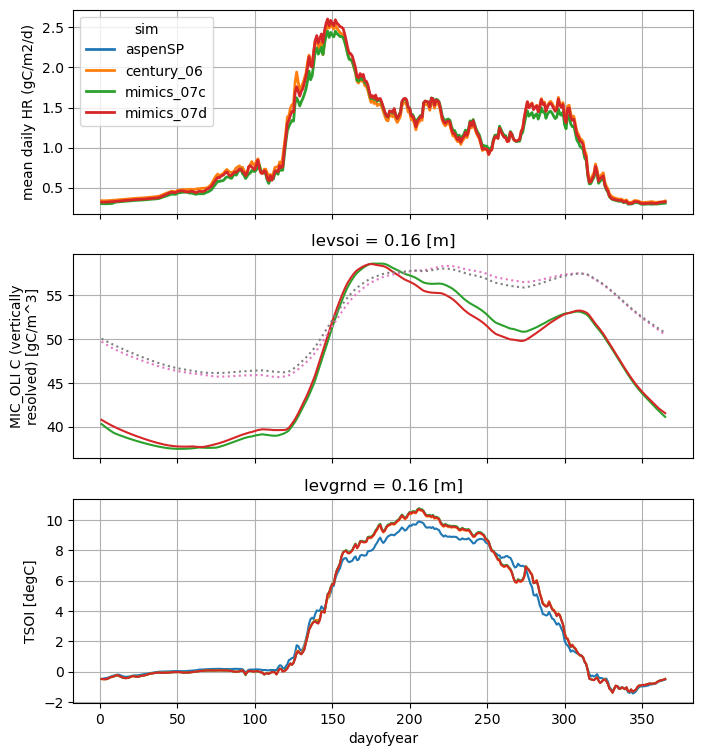

<xarray.Dataset> Size: 19MB
Dimensions:       (time: 5476, sim: 4, levgrnd: 25, levsoi: 20, levdcmp: 26,
                   levlak: 10)
Coordinates:
  * levgrnd       (levgrnd) float32 100B 0.01 0.04 0.09 ... 19.48 28.87 42.0
  * levsoi        (levsoi) float32 80B 0.01 0.04 0.09 0.16 ... 5.95 6.94 8.03
  * levlak        (levlak) float32 40B 0.05 0.6 2.1 4.6 ... 25.6 34.33 44.78
  * levdcmp       (levdcmp) float32 104B 0.01 0.04 0.09 ... 19.48 28.87 42.0
  * sim           (sim) <U10 160B 'aspenSP' 'century_06' ... 'mimics_07d'
  * time          (time) object 44kB 2011-01-01 00:00:00 ... 2026-01-01 00:00:00
Data variables: (12/48)
    mcdate        (time, sim) float64 175kB dask.array<chunksize=(2555, 1), meta=np.ndarray>
    mcsec         (time, sim) float64 175kB dask.array<chunksize=(2555, 1), meta=np.ndarray>
    mdcur         (time, sim) float64 175kB dask.array<chunksize=(2555, 1), meta=np.ndarray>
    mscur         (time, sim) float64 175kB dask.array<chunksize=(2555, 1), meta=np.ndarray>
    nstep         (time, sim) float64 175kB dask.array<chunksize=(2555, 1), meta=np.ndarray>
    lon           (time, sim) float32 88kB dask.array<chunksize=(2555, 1), meta=np.ndarray>
    ...            ...
    MIC_OLI_C_vr  (time, sim, levsoi) float32 2MB dask.array<chunksize=(2555, 1, 20), meta=np.ndarray>
    PPT           (time, sim) float64 175kB dask.array<chunksize=(2555, 1), meta=np.ndarray>
    TSA_min       (sim, time) float32 88kB dask.array<chunksize=(1, 2555), meta=np.ndarray>
    TSA_max       (sim, time) float32 88kB dask.array<chunksize=(1, 2555), meta=np.ndarray>
    SR2           (time, sim) float32 88kB dask.array<chunksize=(2555, 1), meta=np.ndarray>
    HR_frac       (time, sim) float32 88kB dask.array<chunksize=(2555, 1), meta=np.ndarray>
Attributes: (12/39)
    title:                                CLM History file information
    comment:                              NOTE: None of the variables are wei...
    Conventions:                          CF-1.0
    history:                              created on 07/31/25 18:49:36
    source:                               Community Terrestrial Systems Model
    hostname:                             derecho
    ...                                   ...
    ctype_urban_pervious_road:            75
    cft_c3_crop:                          1
    cft_c3_irrigated:                     2
    time_period_freq:                     minute_30
    Time_constant_3Dvars_filename:        ./aspen_sp52.028_PPT1.25_b_Sturm_2o...
    Time_constant_3Dvars:                 ZSOI:DZSOI:WATSAT:SUCSAT:BSW:HKSAT:...

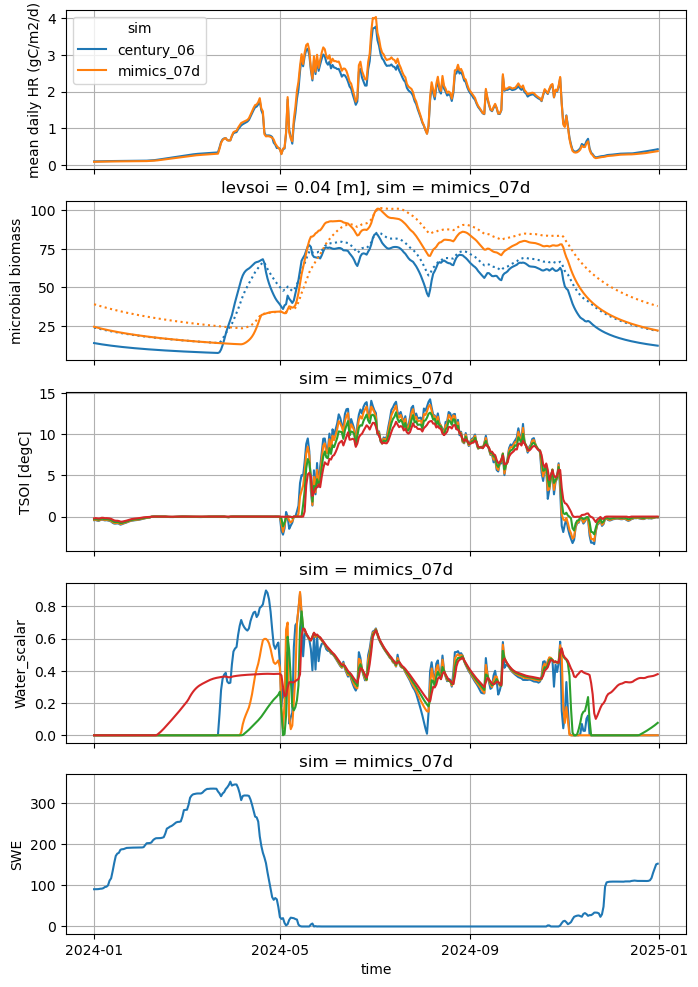

In [107]:
fig, axs = plt.subplots(5, 1, figsize=(8,12),sharex=True)
(ds_daily.isel(sim=[1,3],time=slice((365*13),(365*14))).HR*spd).plot(hue='sim',ax=axs[0])
axs[0].set_xlabel(None)
axs[0].set_ylabel('mean daily HR (gC/m2/d)')
axs[0].grid()

ds_daily.isel(sim=3,time=slice((365*13),(365*14))).MIC_COP_C_vr.isel(levsoi=0).plot(color='tab:blue', ax=axs[1]);
ds_daily.isel(sim=3,time=slice((365*13),(365*14))).MIC_OLI_C_vr.isel(levsoi=0).plot(color='tab:blue', linestyle=':',ax=axs[1]) ;

ds_daily.isel(sim=3,time=slice((365*13),(365*14))).MIC_COP_C_vr.isel(levsoi=1).plot(color='tab:orange', ax=axs[1]);
ds_daily.isel(sim=3,time=slice((365*13),(365*14))).MIC_OLI_C_vr.isel(levsoi=1).plot(color='tab:orange', linestyle=':',ax=axs[1]) ;
axs[1].set_ylabel('microbial biomass')
axs[1].set_xlabel(None)
axs[1].grid()

ds_daily.isel(sim=3,time=slice((365*13),(365*14))).TSOI.isel(levgrnd=slice(0,4)).plot(hue='levgrnd',add_legend=False,ax=axs[2])
axs[2].grid() ;
axs[2].set_xlabel(None)

ds_daily.isel(sim=3,time=slice((365*13),(365*14))).W_SCALAR.isel(levsoi=slice(0,4)).plot(hue='levsoi',add_legend=False,ax=axs[3])
axs[3].set_ylabel('Water_scalar')
axs[3].grid() ;
axs[3].set_xlabel(None)

ds_daily.isel(sim=3,time=slice((365*13),(365*14))).H2OSNO.plot(add_legend=False,ax=axs[4])
axs[4].set_ylabel('SWE')
axs[4].grid() ;
#ds_daily.isel(sim=3,time=slice((365*13),(365*14))).HR.plot()
#snod_flux.set_index(['date','site'])#.to_xarray()
ds_daily

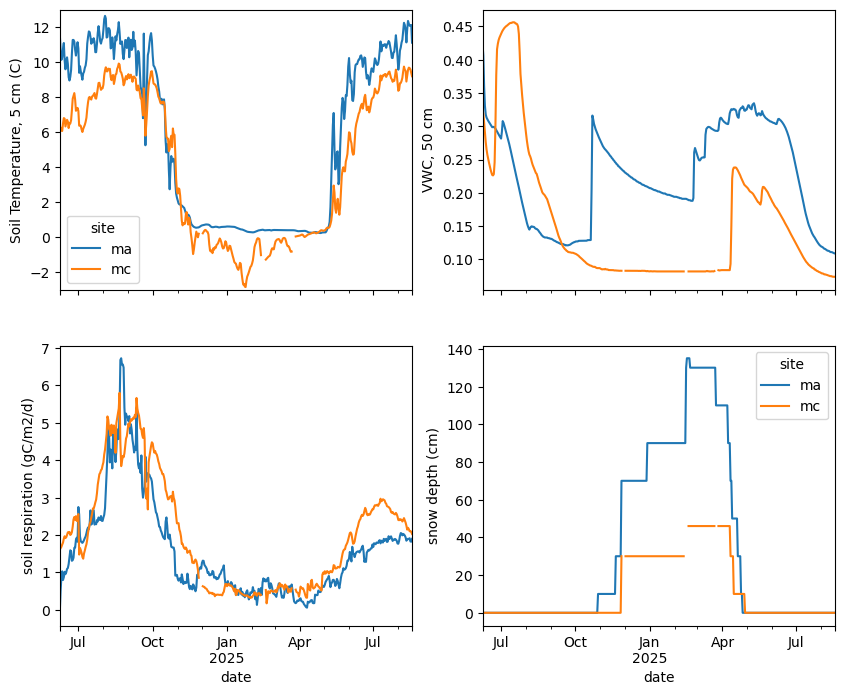

In [101]:
fig, axs = plt.subplots(2, 2, figsize=(10,8),sharex=True)
(snod_flux2.T_3_Avg-273.15).plot(ax=axs[0,0], legend='lower left') 
axs[0,0].set_ylabel('Soil Temperature, 5 cm (C)')
axs[0,0].set_ylim(-3,13)

#(snod_flux2.T_2_Avg-273.17).plot(ax=axs[0,1], legend=False) ;
#axs[0,1].set_ylabel('Soil Temperature, 15 cm (C)')
#axs[0,1].set_ylim(-3,13)

(snod_flux2.VWC_1_Avg).plot(ax=axs[0,1], legend=False) ;
axs[0,1].set_ylabel('VWC, 50 cm')


snod_flux2.SR.plot(ax=axs[1,0], legend=False) ;
axs[1,0].set_ylabel('soil respiration (gC/m2/d)')

snod_flux2['snow.depth'].plot(ax=axs[1,1]) ;
axs[1,1].set_ylabel('snow depth (cm)') ;

## Look at monthly history files 

In [39]:
# -- read only these variables from the whole netcdf files
def preprocess_mim(ds):
    variables = ['GPP', 'NPP', 'ELAI', 'NEP', 'AR', 'ER',
                 'NET_NMIN', 'GROSS_NMIN', 'HR','SMINN',
                 'TOTLITC', 'TOTSOMC', 'TOTVEGC', 'TOTMICC',
                 'TOTLITN', 'TOTSOMN', 'TOTVEGN', 'TOTMICN',
                 'SOILC_vr', 'SOILN_vr', 'SMINN_vr',
                ]
    litvars = ['LIT_MET_C_vr','LIT_STR_C_vr','LIT_MET_N_vr','LIT_STR_N_vr']
    micvars = ['MIC_COP_C_vr','MIC_OLI_C_vr']
    somvars = ['SOM_AVL_C_vr','SOM_CHEM_C_vr','SOM_PHYS_C_vr']
    somvars = somvars + ['SOM_AVL_N_vr','SOM_CHEM_N_vr','SOM_PHYS_N_vr']
    variables = variables + litvars + micvars + somvars

    ds_new = ds[variables].isel(lndgrid=0)
    ds_new['LITC_vr'] = ds_new.LIT_MET_C_vr + ds_new.LIT_STR_C_vr
    ds_new['MICC_vr'] = ds_new.MIC_COP_C_vr + ds_new.MIC_OLI_C_vr

    return ds_new

# -- read only these variables from the whole netcdf files
def preprocess_cen(ds):
    variables = ['GPP', 'NPP', 'ELAI', 'NEP', 'AR', 'ER',
                 'NET_NMIN', 'GROSS_NMIN', 'HR',
                 'TOTLITC', 'TOTSOMC', 'TOTVEGC',
                 'TOTLITN', 'TOTSOMN', 'TOTVEGN',
                 'SOILC_vr', 'SOILN_vr', 'SMINN', 'SMINN_vr',
                ]
    litvars = ['LIT_MET_C_vr', 'LIT_CEL_C_vr', 'LIT_LIG_C_vr']
    somvars = ['SOM_ACT_C_vr', 'SOM_SLO_C_vr', 'SOM_PAS_C_vr']
    variables = variables + litvars + somvars
    ds_new = ds[variables].isel(lndgrid=0)
    ds_new['LITC_vr'] = ds_new.LIT_MET_C_vr + ds_new.LIT_CEL_C_vr + ds_new.LIT_LIG_C_vr

    return ds_new


In [56]:
exp = ['aspen_sp52.028_PPT1.25_b_Sturm_2org',
       'aspen_bgc_52.028_PPT1.25_b_Sturm_2org_zbed_century_06_HISTco2',
       'aspen_bgc_52.028_PPT1.25_b_Sturm_2org_zbed_mimics_06bugfix_HIST',
       'aspen_bgc_52.028_PPT1.25_b_Sturm_2org_zbed_mimics_07b_HIST',
      ]
sim = ['aspenSP',
       'century_06',
       'mimics_06bugFix',
       'mimics_07b',
      ]


In [57]:
hist_year = '.clm2.h0.2011*.nc'
for i in range(1,4):
    f_in = '/glade/derecho/scratch/wwieder/nldas/gothic/archive/'+exp[i]+'/lnd/hist/'
    fin = sorted(glob(f_in+exp[i]+hist_year))
    if i == 1:
        ds_temp = xr.open_mfdataset(fin, decode_times=True, preprocess=preprocess_cen)
        ds0 = ds_temp
    else:
        ds_temp = xr.open_mfdataset(fin, decode_times=True, preprocess=preprocess_mim)
        ds0 = xr.concat([ds0, ds_temp],dim='sim')
    print('opened '+exp[i])

ds0 = ds0.assign_coords({"sim": sim[1:4]})

opened aspen_bgc_52.028_PPT1.25_b_Sturm_2org_zbed_century_06_HISTco2
opened aspen_bgc_52.028_PPT1.25_b_Sturm_2org_zbed_mimics_06bugfix_HIST
opened aspen_bgc_52.028_PPT1.25_b_Sturm_2org_zbed_mimics_07b_HIST


#### Plot vertical profiles

''

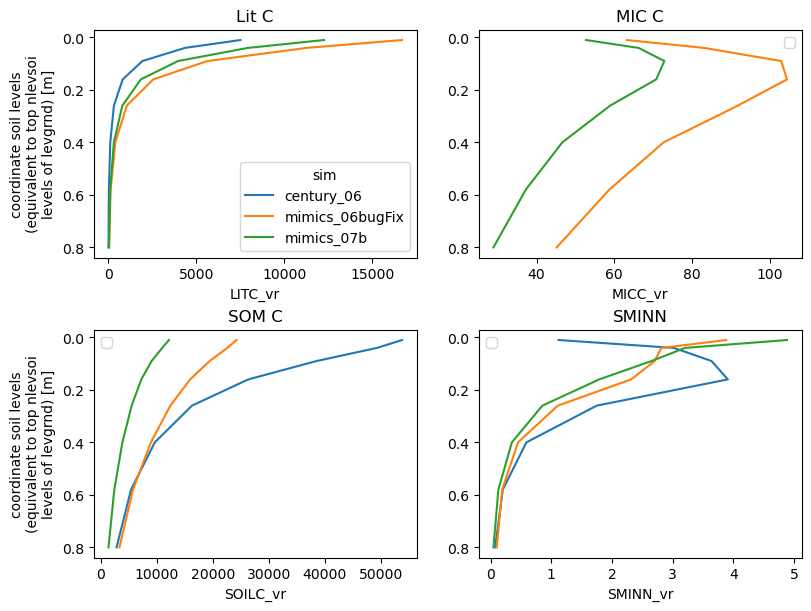

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6), 
                         layout='constrained')
ax = axes[0,0]
ds0.LITC_vr.mean('time') \
          .isel(levsoi=slice(0,8)) \
          .plot(y='levsoi',hue='sim', ax=ax) 
#ax.legend()
#ax.set_xscale('log')
ax.invert_yaxis() 
ax.set_title('Lit C')

ax = axes[0,1]
ds0.MICC_vr.mean('time') \
           .isel(levsoi=slice(0,8)) \
           .plot(y='levsoi',hue='sim', ax=ax) 
ax.legend([])
#plt.xscale('log')
ax.invert_yaxis()
ax.set_ylabel(None)
ax.set_title('MIC C')

ax = axes[1,0]
ds0.SOILC_vr.mean('time') \
           .isel(levsoi=slice(0,8)) \
           .plot(y='levsoi',hue='sim', ax=ax) 
ax.legend([])
#ax.set_xscale('log')
ax.invert_yaxis() 
ax.set_title('SOM C')

ax = axes[1,1]
ds0.SMINN_vr.mean('time') \
           .isel(levsoi=slice(0,8)) \
           .plot(y='levsoi',hue='sim', ax=ax) 
ax.legend([])
#ax.set_xscale('log')
ax.set_ylabel(None) 
ax.invert_yaxis()
ax.set_title('SMINN')

;

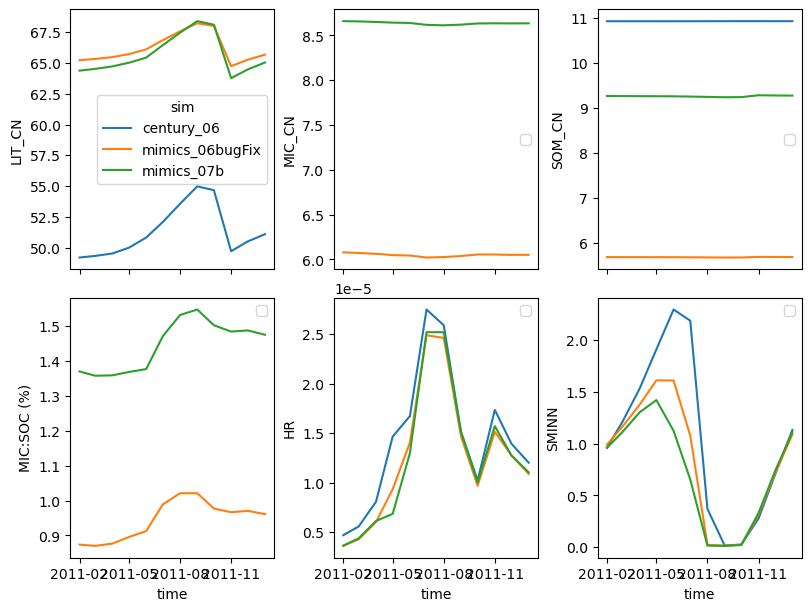

In [69]:
fig, axes = plt.subplots(2, 3, figsize=(8, 6), sharex=True,
                         layout='constrained')
ax = axes[0,0]
ds0['LIT_CN'] = ds0.TOTLITC / ds0.TOTLITN
ds0['LIT_CN'].plot(hue='sim',ax=ax)
ax.set_xlabel(None) 

ax = axes[0,1]
ds0['MIC_CN'] = ds0.TOTMICC / ds0.TOTMICN
ds0['MIC_CN'].plot(hue='sim',ax=ax)
ax.set_xlabel(None) 
ax.legend([])

ax = axes[0,2]
ds0['SOM_CN'] = ds0.TOTSOMC / ds0.TOTSOMN
ds0['SOM_CN'].plot(hue='sim',ax=ax) ;
ax.set_xlabel(None) 
ax.legend([])

ax = axes[1,0]
ds0['MIC:SOC'] = 100*ds0.TOTMICC / ds0.TOTSOMC
ds0['MIC:SOC'].plot(hue='sim',ax=ax) 
ax.legend([])
ax.set_ylabel('MIC:SOC (%)') ;

ax = axes[1,1]
ds0['HR'].plot(hue='sim',ax=ax) 
ax.legend([])
ax.set_ylabel('HR') 

ax = axes[1,2]
ds0['SMINN'].plot(hue='sim',ax=ax) 
ax.set_ylabel('SMINN') 
ax.legend([]) ;


Text(0, 0.5, '')

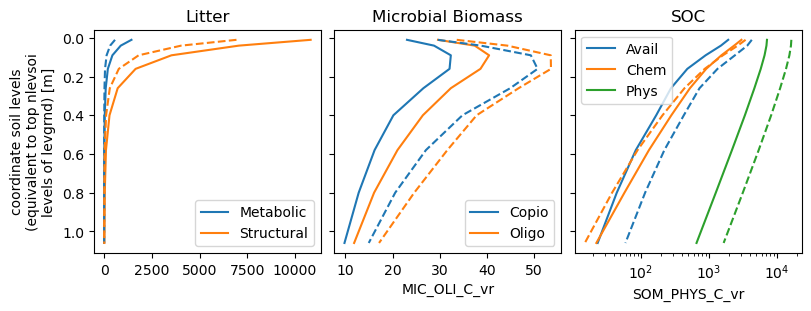

In [60]:
# MIMICS pool distributions
nSim = 2  # Main simulation number (2 = MIMICS test)
nComp = 1 # comparision (0 = CENTURY, 1 = MIMICS base)
layerBot = 9
fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharey=True,
                         layout='constrained')
ax = axes[0]
ds0.LIT_MET_C_vr.mean('time').isel(sim=nSim) \
          .isel(levsoi=slice(0,layerBot)) \
          .plot(y='levsoi', ax=ax , label="Metabolic") 
ds0.LIT_STR_C_vr.mean('time').isel(sim=nSim) \
          .isel(levsoi=slice(0,layerBot)) \
          .plot(y='levsoi', ax=ax , label="Structural") 
ax.legend()
ds0.LIT_MET_C_vr.mean('time').isel(sim=0) \
          .isel(levsoi=slice(0,layerBot)) \
          .plot(y='levsoi', ax=ax , label="Century MET", color='tab:blue', linestyle ='--') 
(ds0.LIT_CEL_C_vr+ds0.LIT_LIG_C_vr).mean('time').isel(sim=0) \
          .isel(levsoi=slice(0,layerBot)) \
          .plot(y='levsoi', ax=ax , label="Century STR", color='tab:orange', linestyle ='--') 
#ax.set_xscale('log')
ax.invert_yaxis() 
ax.set_title('Litter')

ax = axes[1]
ds0.MIC_COP_C_vr.mean('time').isel(sim=nSim) \
           .isel(levsoi=slice(0,layerBot)) \
           .plot(y='levsoi',ax=ax, label="Copio") 
ds0.MIC_OLI_C_vr.mean('time').isel(sim=nSim) \
           .isel(levsoi=slice(0,layerBot)) \
           .plot(y='levsoi',ax=ax, label="Oligo") 
ax.legend()
if nComp == 1:
    ds0.MIC_COP_C_vr.mean('time').isel(sim=nComp) \
               .isel(levsoi=slice(0,layerBot)) \
               .plot(y='levsoi',ax=ax, label="Copio", color='tab:blue', linestyle = '--') 
    ds0.MIC_OLI_C_vr.mean('time').isel(sim=nComp) \
               .isel(levsoi=slice(0,layerBot)) \
               .plot(y='levsoi',ax=ax, label="Oligo", color='tab:orange', linestyle = '--') 

#plt.xscale('log')
ax.invert_yaxis() 
ax.set_ylabel(None)
ax.set_title('Microbial Biomass');

ax = axes[2]
ds0.SOM_AVL_C_vr.mean('time').isel(sim=nSim) \
           .isel(levsoi=slice(0,layerBot)) \
           .plot(y='levsoi',ax=ax,label="Avail") 
ds0.SOM_CHEM_C_vr.mean('time').isel(sim=nSim) \
           .isel(levsoi=slice(0,layerBot)) \
           .plot(y='levsoi',ax=ax,label="Chem") 
ds0.SOM_PHYS_C_vr.mean('time').isel(sim=nSim) \
           .isel(levsoi=slice(0,layerBot)) \
           .plot(y='levsoi',ax=ax,label="Phys") 
ax.legend()

if nComp == 0:
    ds0.SOM_ACT_C_vr.mean('time').isel(sim=nComp) \
           .isel(levsoi=slice(0,layerBot)) \
           .plot(y='levsoi',ax=ax,label="SOM1", color='tab:blue', linestyle = '--') 
    ds0.SOM_SLO_C_vr.mean('time').isel(sim=nComp) \
           .isel(levsoi=slice(0,layerBot)) \
           .plot(y='levsoi',ax=ax,label="SOM2", color='tab:orange', linestyle = '--') 
    ds0.SOM_PAS_C_vr.mean('time').isel(sim=nComp) \
           .isel(levsoi=slice(0,layerBot)) \
           .plot(y='levsoi',ax=ax,label="SOM3", color='tab:green', linestyle = '--') 
else:
    ds0.SOM_AVL_C_vr.mean('time').isel(sim=nComp) \
           .isel(levsoi=slice(0,layerBot)) \
           .plot(y='levsoi',ax=ax,label="Avail", color='tab:blue', linestyle = '--') 
    ds0.SOM_CHEM_C_vr.mean('time').isel(sim=nComp) \
           .isel(levsoi=slice(0,layerBot)) \
           .plot(y='levsoi',ax=ax,label="Chem", color='tab:orange', linestyle = '--') 
    ds0.SOM_PHYS_C_vr.mean('time').isel(sim=nComp) \
           .isel(levsoi=slice(0,layerBot)) \
           .plot(y='levsoi',ax=ax,label="Phys", color='tab:green', linestyle = '--') 

ax.set_xscale('log')
ax.invert_yaxis() 
ax.set_title('SOC')
ax.set_ylabel(None)

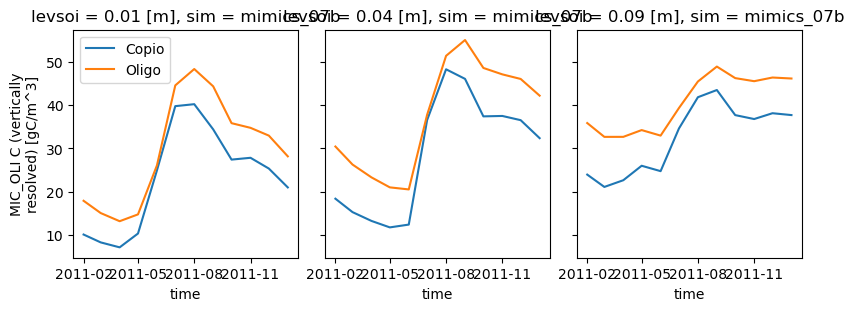

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharey=True,
                     layout='constrained')
for i in range(3):
    ax = axes[i]
    ds0.MIC_COP_C_vr.isel(sim=nSim,levsoi=i) \
               .plot(x='time',ax=ax, label="Copio") 
    ds0.MIC_OLI_C_vr.isel(sim=nSim,levsoi=i) \
               .plot(x='time',ax=ax, label="Oligo")
    
    if i == 0: 
        ax.legend()
        ax.set_title='MIC'
    else:
        ax.set_ylabel(None)


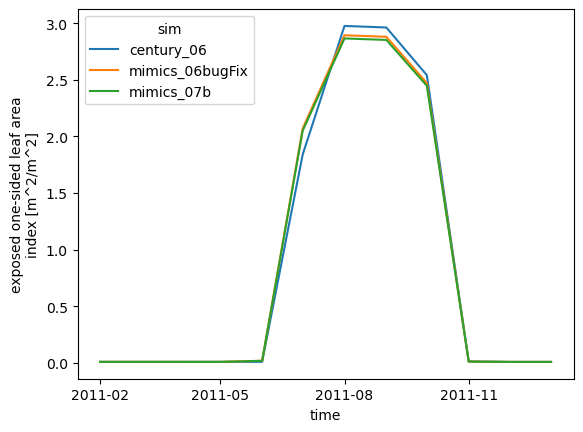

In [62]:
ds0.ELAI.plot(hue='sim')

---
## Go back to snodgrass soil measurements

Text(0, 0.5, 'Soil Moisture, 15 cm')

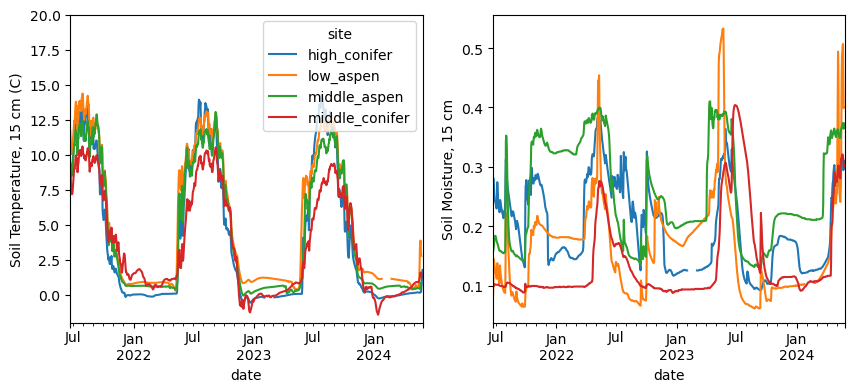

In [99]:
#obs_soil.set_index('date', inplace=True)
#obs_soil.set_index('site', inplace=True)


Text(0, 0.5, 'Soil Moisture, 50 cm')

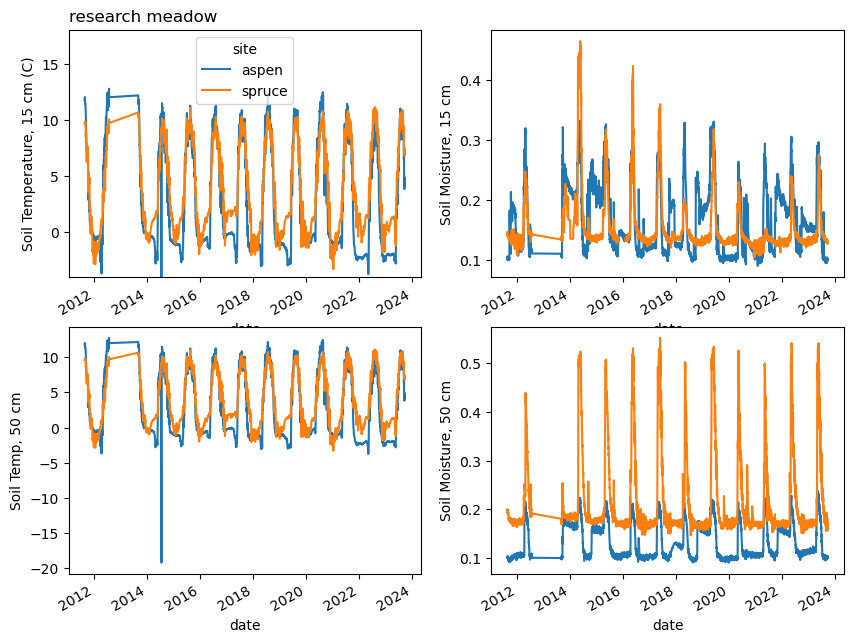

In [100]:
obs_soil = obs_path + 'research_meadow_soil_env.csv'
obs_soil = pd.read_csv(obs_soil)
obs_soil['date'] = pd.to_datetime(obs_soil['date'])
day_soil = obs_soil.groupby([obs_soil.date,obs_soil.site]).mean().unstack()

fig, axs = plt.subplots(2, 2, figsize=(10,8))
day_soil.st15.plot(ax=axs[0,0], legend='lower left') 
axs[0,0].set_ylabel('Soil Temperature, 15 cm (C)')
axs[0,0].set_ylim(-4,18)
axs[0,0].set_title('research meadow',loc='left')
day_soil.vwc15.plot(ax=axs[0,1], legend=False) ;
axs[0,1].set_ylabel('Soil Moisture, 15 cm')
day_soil.st15.plot(ax=axs[1,0], legend=False) ;
axs[1,0].set_ylabel('Soil Temp, 50 cm')

day_soil.vwc50.plot(ax=axs[1,1], legend=False) ;
axs[1,1].set_ylabel('Soil Moisture, 50 cm')


site
aspen     Axes(0.125,0.11;0.775x0.77)
spruce    Axes(0.125,0.11;0.775x0.77)
Name: vwc15, dtype: object

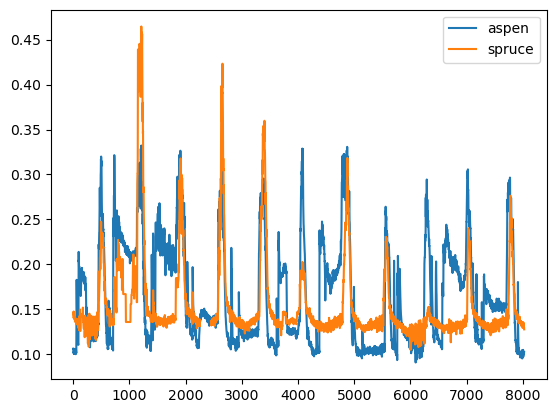

In [ ]:
obs_soil.groupby('site')['vwc15'].plot(legend='True')

In [ ]:
obs15Max = obs_soil.groupby([obs_soil.date.dt.year,obs_soil.site]).max().unstack().vwc15
obs15Max = obs_soil.groupby(obs_soil.site).max().unstack().vwc15
obs50Max = obs_soil.groupby(obs_soil.site).max().unstack().vwc50
obs15Max

site
aspen     0.332208
spruce    0.464542
dtype: object

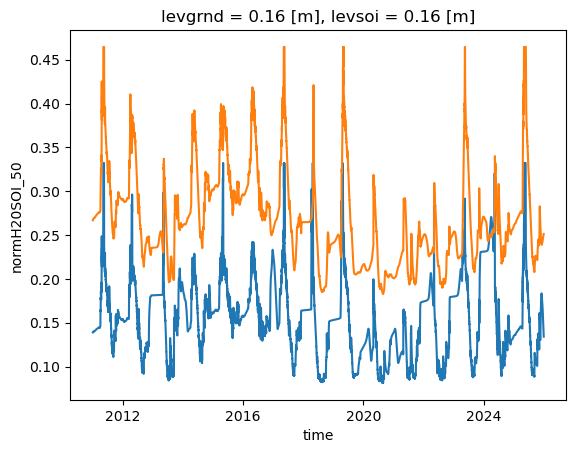

In [ ]:
# Normalize soil moisure to soil level max
ds1['normH2OSOI'] =  ds1.H2OSOI / ds1.H2OSOI.max('time')
ds2['normH2OSOI'] =  ds2.H2OSOI / ds2.H2OSOI.max('time')
#ds.normH2OSOI.isel(lndgrid=0,levsoi=3).plot()
#ds_noLW.normH2OSOI.isel(lndgrid=0,levsoi=3).plot()

spd = 60 * 60 * 24
ds_asp = xr.Dataset()
ds_asp['TSOI_15'] = ds1.TSOI.isel(lndgrid=0,levgrnd=3)
ds_asp['TSOI_50'] = ds1.TSOI.isel(lndgrid=0,levgrnd=5)
ds_asp['normH20SOI_15'] = ds1.normH2OSOI.isel(lndgrid=0,levsoi=3) * obs15Max[0]
ds_asp['normH20SOI_50'] = ds1.normH2OSOI.isel(lndgrid=0,levsoi=5) * obs15Max[1]
ds_asp['RAIN'] = ds1.RAIN.isel(lndgrid=0) * spd
ds_asp['SNOW'] = ds1.SNOW.isel(lndgrid=0) * spd
ds_asp['normH20SOI_15'].plot()
ds_asp['normH20SOI_50'].plot() ;
fout = '/glade/derecho/scratch/wwieder/nldas/gothic/'+exp[0]+'daily.csv'
#ds_asp.to_dataframe().to_csv(fout)
#print(fout)

In [ ]:
# Climo of daily means
ds_hist1 = ds1.isel(lndgrid=0).groupby('time.dayofyear').mean()
#ds_ssp = ds.isel(time=slice((-365*20),None), lndgrid=0).groupby('time.dayofyear').mean()

ds_hist2 = ds2.isel(lndgrid=0).groupby('time.dayofyear').mean()
#ds_ssp2 = ds_noLW.isel(time=slice((-365*20),None), lndgrid=0).groupby('time.dayofyear').mean()

colors = ['tab:blue','tab:orange']
dsHist = xr.concat([ds_hist1,ds_hist2],'sim').assign_coords({"sim": exp})
#dsSSP = xr.concat([ds_ssp,ds_ssp2],'sim').assign_coords({"sim": exp})

### Plots for Hist vs. Obs

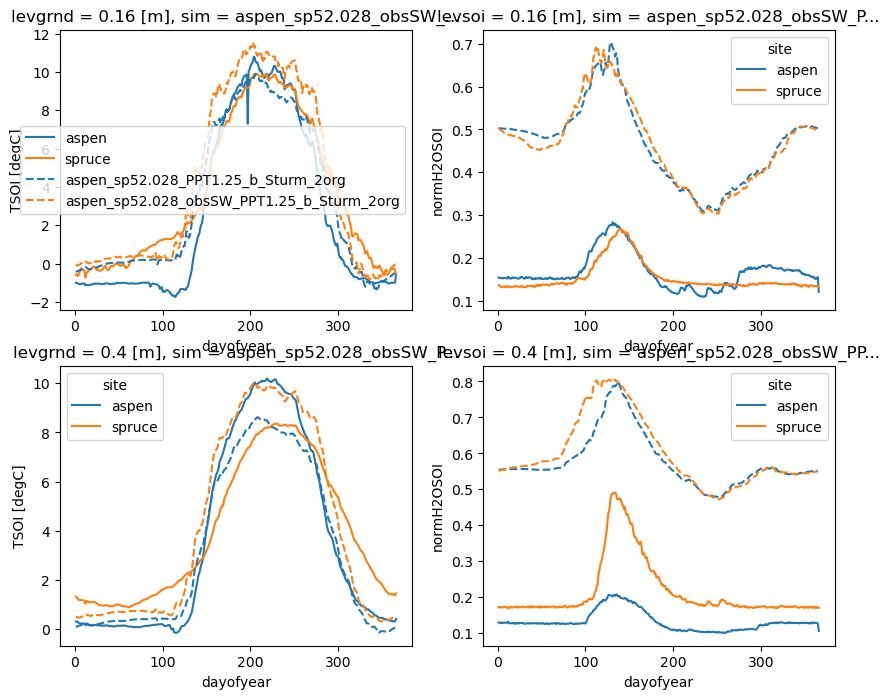

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(10,8))

obs_soil.groupby([obs_soil.date.dt.dayofyear,obs_soil.site]).mean().unstack().st15.plot(ax=axs[0,0]) ;
obs_soil.groupby([obs_soil.date.dt.dayofyear,obs_soil.site]).mean().unstack().st50.plot(ax=axs[1,0]) ;
obs_soil.groupby([obs_soil.date.dt.dayofyear,obs_soil.site]).mean().unstack().vwc15.plot(ax=axs[0,1]) ;
obs_soil.groupby([obs_soil.date.dt.dayofyear,obs_soil.site]).mean().unstack().vwc50.plot(ax=axs[1,1]) ;

for i in range(2):
    dsHist.TSOI.isel(levgrnd=3,sim=i).plot(c=colors[i], linestyle='dashed', ax=axs[0,0],label=exp[i])
    dsHist.TSOI.isel(levgrnd=5,sim=i).plot(c=colors[i], linestyle='dashed', ax=axs[1,0],label=exp[i])
    dsHist.normH2OSOI.isel(levsoi=3,sim=i).plot(c=colors[i], linestyle='dashed',
                                                              ax=axs[0,1], label=exp[i])
    dsHist.normH2OSOI.isel(levsoi=5,sim=i).plot(c=colors[i], linestyle='dashed',
                                                              ax=axs[1,1], label=exp[i])
    #dsHist.H2OSNO.isel(sim=i).plot(c=colors[i], linestyle='dashed', ax=axs[1,1])
ax = axs[0,0]
ax.legend()


### Plots for Hist vs. SSP

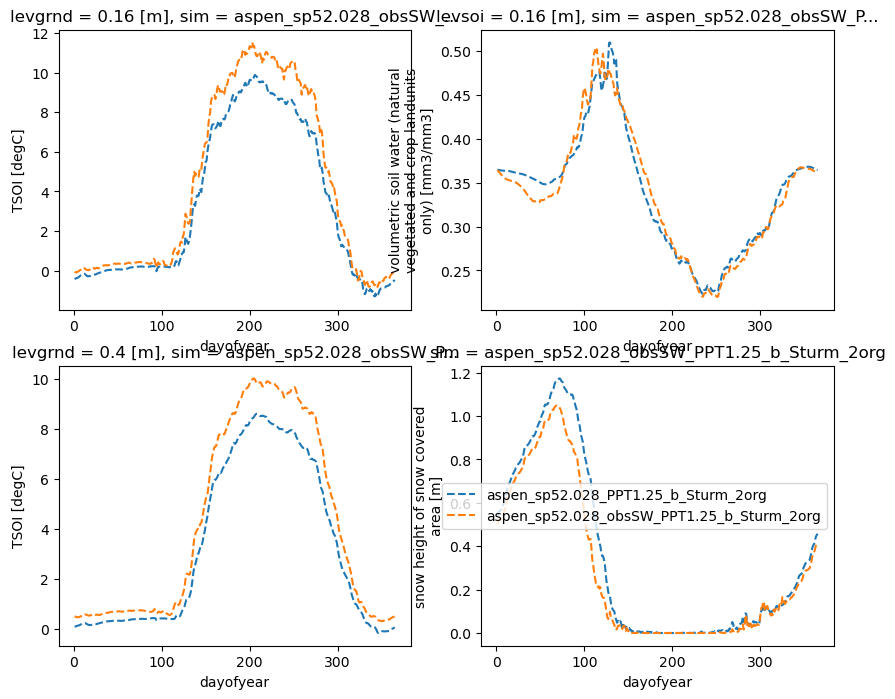

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(10,8))
for i in range(2):
    dsHist.TSOI.isel(levgrnd=3,sim=i).plot(c=colors[i], linestyle='dashed', ax=axs[0,0])
    #dsSSP.TSOI.isel(levgrnd=3, sim=i).plot(c=colors[i], linestyle='dotted', ax=axs[0,0]) 

    dsHist.TSOI.isel(levgrnd=5,sim=i).plot(c=colors[i], linestyle='dashed', ax=axs[1,0])
    #dsSSP.TSOI.isel(levgrnd=5, sim=i).plot(c=colors[i], linestyle='dotted', ax=axs[1,0]) 

    dsHist.H2OSOI.isel(levsoi=3,sim=i).plot(c=colors[i], linestyle='dashed', ax=axs[0,1])
    #dsSSP.H2OSOI.isel(levsoi=3, sim=i).plot(c=colors[i], linestyle='dotted', ax=axs[0,1]) 

    dsHist.SNOW_DEPTH.isel(sim=i).plot(c=colors[i], linestyle='dashed', ax=axs[1,1],label=exp[i])
    #dsSSP.H2OSNO.isel(sim=i).plot(c=colors[i], linestyle='dotted', ax=axs[1,1]) ;
ax = axs[1,1]
ax.legend()

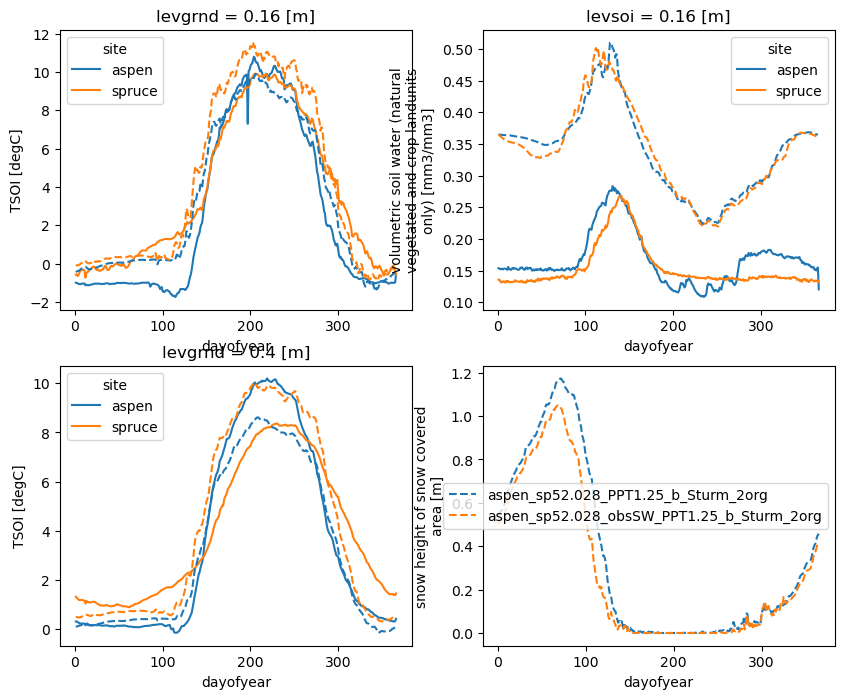

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(10,8))
obs_soil.groupby([obs_soil.date.dt.dayofyear,obs_soil.site]).mean().unstack().st15.plot(ax=axs[0,0]) ;
ds1.TSOI.isel(levgrnd=3, lndgrid=0).groupby('time.dayofyear').mean().plot(
    label=exp[0],ax=axs[0,0],color='tab:blue',linestyle="dashed") ;
ds2.TSOI.isel(levgrnd=3, lndgrid=0).groupby('time.dayofyear').mean().plot(
    label=exp[1],ax=axs[0,0],color='tab:orange',linestyle="dashed") ;

obs_soil.groupby([obs_soil.date.dt.dayofyear,obs_soil.site]).mean().unstack().st50.plot(ax=axs[1,0]) ;
ds1.TSOI.isel(levgrnd=5, lndgrid=0).groupby('time.dayofyear').mean().plot(
    label=exp[0],ax=axs[1,0],color='tab:blue',linestyle="dashed") ;
ds2.TSOI.isel(levgrnd=5, lndgrid=0).groupby('time.dayofyear').mean().plot(
    label=exp[1],ax=axs[1,0],color='tab:orange',linestyle="dashed") ;

obs_soil.groupby([obs_soil.date.dt.dayofyear,obs_soil.site]).mean().unstack().vwc15.plot(ax=axs[0,1]) ;
ds1.H2OSOI.isel(levsoi=3, lndgrid=0).groupby('time.dayofyear').mean().plot(
    label=exp[0],ax=axs[0,1],color='tab:blue',linestyle="dashed") ;
ds2.H2OSOI.isel(levsoi=3, lndgrid=0).groupby('time.dayofyear').mean().plot(
    label=exp[1],ax=axs[0,1],color='tab:orange',linestyle="dashed") ;
#axs[0,1].legend()

ds1.SNOW_DEPTH.isel(lndgrid=0).groupby('time.dayofyear').mean().plot(
    label=exp[0],ax=axs[1,1],color='tab:blue',linestyle="dashed") ;
ds2.SNOW_DEPTH.isel(lndgrid=0).groupby('time.dayofyear').mean().plot(
    label=exp[1],ax=axs[1,1],color='tab:orange',linestyle="dashed") ;
axs[1,1].legend() ;

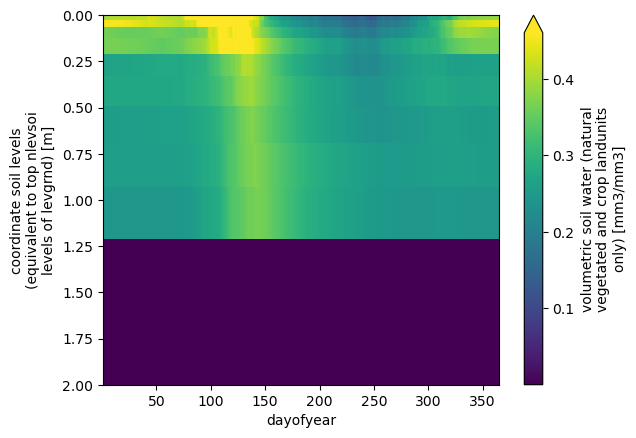

In [ ]:
ds1d.H2OSOI.isel(lndgrid=0).groupby('time.dayofyear').mean().plot(x='dayofyear',robust=True) ;
plt.ylim(0,2)
plt.gca().invert_yaxis()

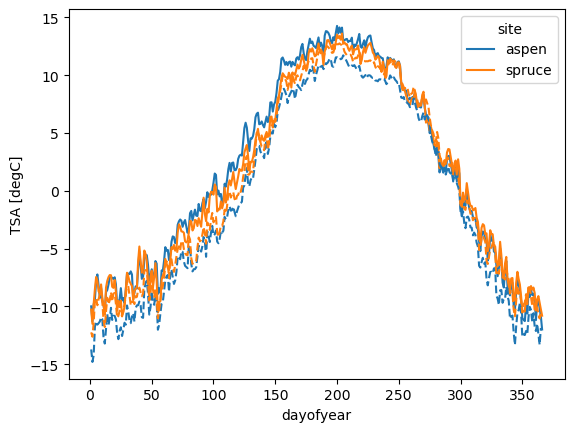

In [ ]:
obs_soil.groupby([obs_soil.date.dt.dayofyear,obs_soil.site]).mean().unstack().airTC.plot() ;
ds1.TSA.isel(lndgrid=0).groupby('time.dayofyear').mean().plot(label=exp[0],color='tab:blue',linestyle="dashed") ;
ds2.TSA.isel(lndgrid=0).groupby('time.dayofyear').mean().plot(label=exp[1],color='tab:orange',linestyle="dashed") ;
#plt.legend() ;

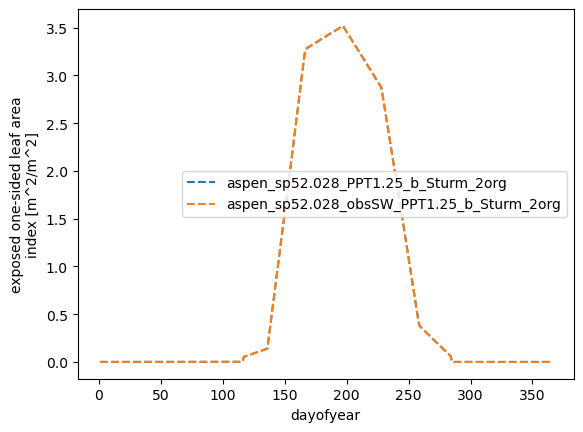

In [ ]:
ds1.ELAI.isel(lndgrid=0).groupby('time.dayofyear').mean().plot(label=exp[0],color='tab:blue',linestyle="dashed") ;
ds2.ELAI.isel(lndgrid=0).groupby('time.dayofyear').mean().plot(label=exp[1],color='tab:orange',linestyle="dashed") 
plt.legend() ;

In [ ]:
obs_soil.groupby([obs_soil.date.dt.dayofyear,obs_soil.site]).mean().unstack().airTC

site,aspen,spruce
date,,
1,-9.995386,-10.273064
2,-11.298034,-11.509682
3,-9.830375,-9.789186
4,-9.393614,-8.507754
5,-7.757451,-7.455625
...,...,...
362,-9.697413,-9.400254
363,-9.434705,-9.107875
364,-10.166117,-9.707614


-2.352224747880168


-0.747241117140205

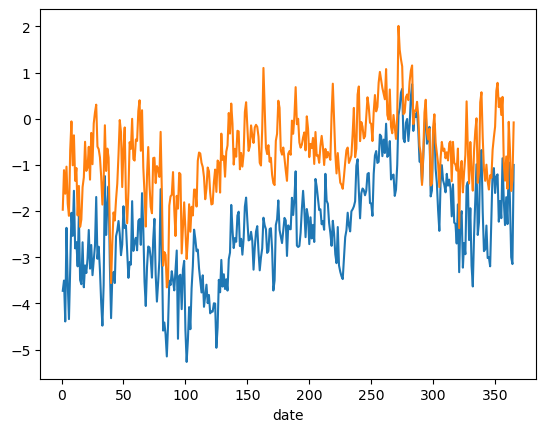

In [ ]:
bias1 = (ds1.TSA.isel(lndgrid=0).groupby('time.dayofyear').mean().values - \
  obs_soil.groupby([obs_soil.date.dt.dayofyear,obs_soil.site]).mean().unstack().airTC['aspen'][0:-1])
bias1.plot()
print(bias1.mean())

bias2 = (ds2.TSA.isel(lndgrid=0).groupby('time.dayofyear').mean().values - \
  obs_soil.groupby([obs_soil.date.dt.dayofyear,obs_soil.site]).mean().unstack().airTC['spruce'][0:-1])
bias2.plot()
bias2.mean()

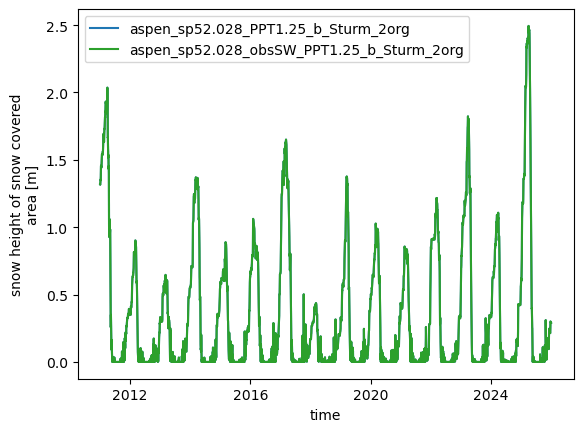

In [ ]:
ds1d.SNOW_DEPTH.plot(label=exp[0])
ds1d.SNOW_DEPTH.plot(label=exp[1],color='tab:green') 
plt.legend();

Text(0, 0.5, 'SWE (mm)')

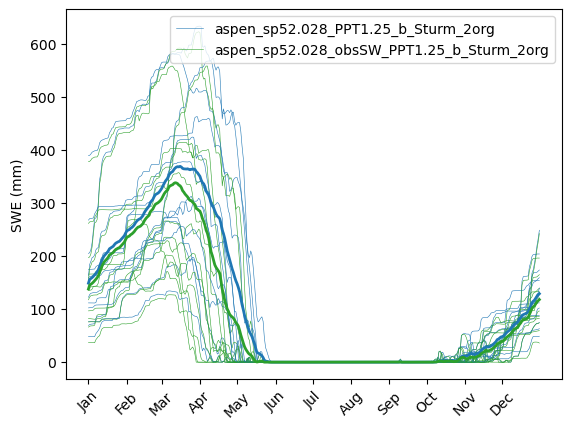

Snotel

<xarray.Dataset>
Dimensions:  (time: 5110, site: 1)
Coordinates:
  * time     (time) datetime64[ns] 2011-01-01 2011-01-02 ... 2024-12-31
  * site     (site) <U5 'Butte'
Data variables:
    SWE      (time, site) float64 221.0 223.5 226.1 228.6 ... 162.6 170.2 175.3
    PPT      (time, site) float64 292.1 292.1 292.1 294.6 ... 182.9 188.0 193.0

In [ ]:
x

range(0, 365)

Text(0, 0.5, 'SWE (mm)')

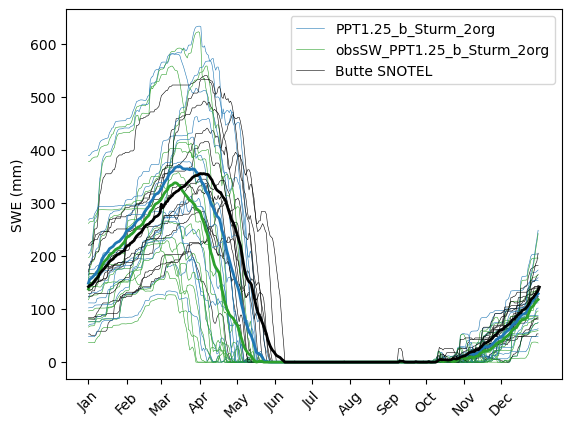

In [ ]:
pltvar = 'H2OSNO'  #2008 & 2011 big snow years
for i in range(13):
    t0 = i*365
    t1 = (i+1)*365
    x = range(0,365)
    x3 = range(0,366)
    y = ds1d[pltvar].isel(time=slice(t0,t1)).isel(lndgrid=0)
    y2 = ds2d[pltvar].isel(time=slice(t0,t1)).isel(lndgrid=0)
    y3 = OBS['SWE'].isel(site=0,time=slice(t0,t1))
    plt.plot(x,y,lw=0.4, color='tab:blue',label=exp[0][15:])#'Aspen, Obs TLS (2000-2019)')
    plt.plot(x,y2,lw=0.4,color='tab:green', label=exp[1][15:])#'Aspen, Obs SW no LW (2012-2022)')
    plt.plot(x,y3,lw=0.4,color='k', label='Butte SNOTEL')#'Aspen, Obs SW no LW (2012-2022)')
    if i == 0: plt.legend() ;
Y = ds1d[pltvar].isel(lndgrid=0).groupby('time.dayofyear').mean()
Y2 = ds2d[pltvar].isel(lndgrid=0).groupby('time.dayofyear').mean()
Y3 = OBS['SWE'].isel(site=0).groupby('time.dayofyear').mean()
plt.plot(x,Y,lw=2,color='tab:blue')
plt.plot(x,Y2,lw=2,color='tab:green')
plt.plot(x3,Y3,lw=2,color='k')
plt.xticks(tick, month[0], rotation=45) 
plt.ylabel('SWE (mm)')

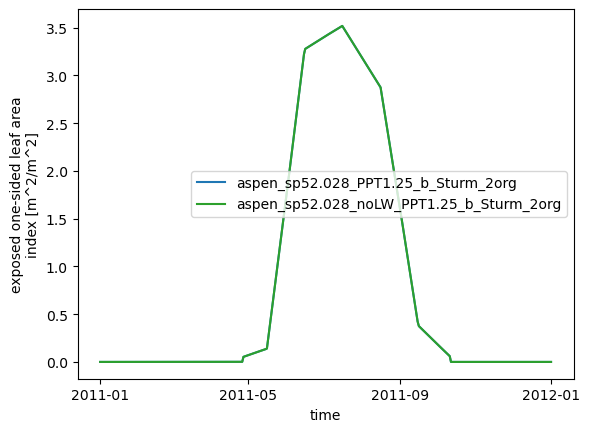

In [ ]:
ds1d.ELAI.isel(time=slice(0,366)).plot(label=exp[0])
ds2d.ELAI.isel(time=slice(0,366)).plot(label=exp[1],color='tab:green')
plt.legend() ;

In [ ]:
year = range(2001, 2020)
year_wy = range(2002, 2021)

# Subset observations to the same range
obs = bb_obs[bb_obs.year>=2001]
obs = obs[obs.year<=2020]
obs['mean_temp'] = (obs['maximum.temperature']+obs['minimum.temperature'])/2

### Make plots comparing model w/ observations

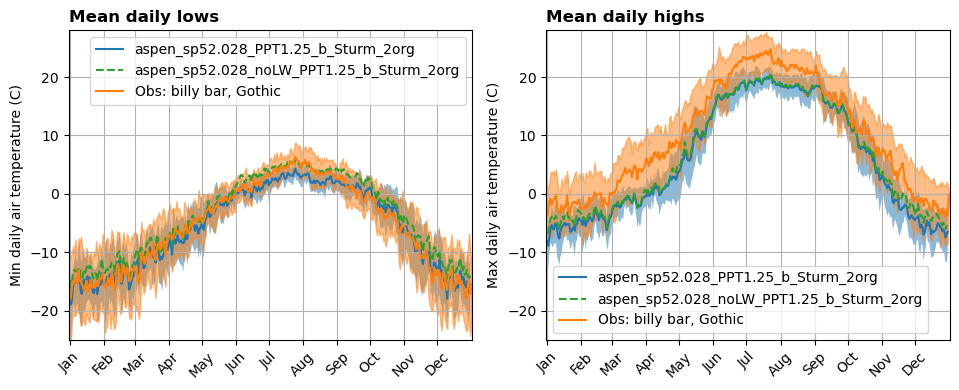

In [ ]:
# Calculate climatology
Y1 = obs.groupby(obs.day_of_year).mean()
Y1b = obs.groupby(obs.day_of_year).std()
x1 = range(0,  366)

x2 = range(0,365)

# Plot min and max temperature
obs_var = ['minimum.temperature', 'maximum.temperature']
ylabel = ['Min daily air temperature (C)', 'Max daily air temperature (C)']
title = ['Mean daily lows', 'Mean daily highs']

fig, axes = plt.subplots(1, 2, figsize=(10,4))

for i in range(2):
    if i == 0: 
        Y2 = ds1Min.groupby('time.dayofyear').mean().isel(lndgrid=0)
        Y2b = ds1Min.groupby('time.dayofyear').std().isel(lndgrid=0)

        Z2 = ds2Min.groupby('time.dayofyear').mean().isel(lndgrid=0)
        #Z2b = ds2Min.groupby('time.dayofyear').std().isel(lndgrid=0)
    else:
        Y2 = ds1Max.groupby('time.dayofyear').mean().isel(lndgrid=0)
        Y2b = ds1Max.groupby('time.dayofyear').std().isel(lndgrid=0)
        Z2 = ds2Max.groupby('time.dayofyear').mean().isel(lndgrid=0)
        #Z2b = ds2Max.groupby('time.dayofyear').std().isel(lndgrid=0)

    axes[i].plot(x2, Y2, label = exp[0])
    axes[i].fill_between(x2, Y2-Y2b, Y2+Y2b, alpha=0.5)

    axes[i].plot(x2, Z2, label = exp[1], color='tab:green',linestyle="--")
    #axes[i].fill_between(x2, Z2-Z2b, Z2+Z2b, alpha=0.5)

    axes[i].set_xticks(tick, month[0], rotation=45)
    axes[i].set_xlim(-1, 366)
    axes[i].set_ylim(-25, 28)
    
    axes[i].plot(x1, Y1[obs_var[i]], label='Obs: billy bar, Gothic',color='tab:orange')
    axes[i].fill_between(x1, Y1[obs_var[i]] - Y1b[obs_var[i]], 
                         Y1[obs_var[i]] + Y1b[obs_var[i]], alpha=0.5,color='tab:orange')
    axes[i].set_ylabel(ylabel[i])
    axes[i].set_title(title[i],loc='left', fontsize='large', fontweight='bold')
    axes[i].legend()
    axes[i].grid() ;
    
fig.tight_layout()

In [ ]:
(Y1[obs_var[i]][0:365]-Y2).mean()

3.822829904152106

['minimum.temperature']
bb obs - NLDAS 0.3600010571712501
NLDAS - Snody Climo -1.8406737
['maximum.temperature']
bb obs - NLDAS 3.822829904152106
NLDAS - Snody Climo -0.8404553


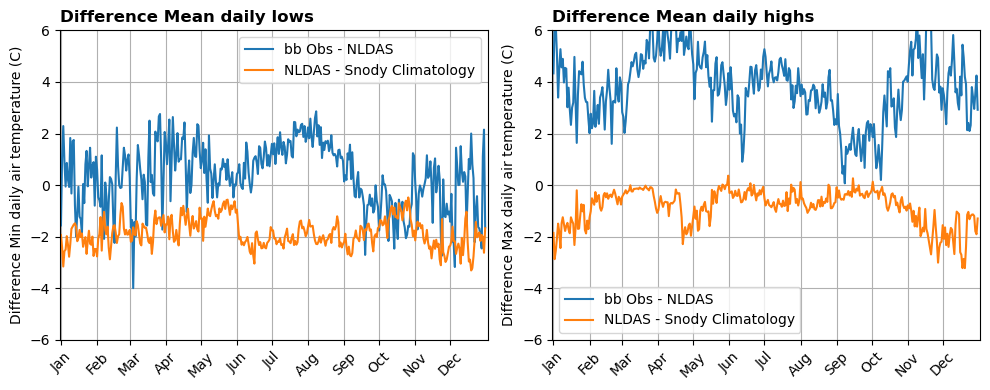

In [ ]:
# Calculate climatology
Y1 = obs.groupby(obs.day_of_year).mean()
Y1b = obs.groupby(obs.day_of_year).std()
x1 = range(0,  366)

x2 = range(0,365)

# Plot min and max temperature
obs_var = ['minimum.temperature', 'maximum.temperature']
ylabel = ['Difference Min daily air temperature (C)', 'Difference Max daily air temperature (C)']
title = ['Difference Mean daily lows', 'Difference Mean daily highs']

fig, axes = plt.subplots(1, 2, figsize=(10,4))

for i in range(2):
    if i == 0: 
        Y2 = ds1Min.groupby('time.dayofyear').mean().isel(lndgrid=0)
        Y2b = ds1Min.groupby('time.dayofyear').std().isel(lndgrid=0)

        Z2 = ds2Min.groupby('time.dayofyear').mean().isel(lndgrid=0)
        #Z2b = ds2Min.groupby('time.dayofyear').std().isel(lndgrid=0)
    else:
        Y2 = ds1Max.groupby('time.dayofyear').mean().isel(lndgrid=0)
        Y2b = ds1Max.groupby('time.dayofyear').std().isel(lndgrid=0)
        Z2 = ds2Max.groupby('time.dayofyear').mean().isel(lndgrid=0)
        #Z2b = ds2Max.groupby('time.dayofyear').std().isel(lndgrid=0)

    axes[i].plot(x2, Y1[obs_var[i]][0:365]-Y2, label = 'bb Obs - NLDAS')
    axes[i].plot(x2, Y2-Z2, label = 'NLDAS - Snody Climatology')
    print([obs_var[i]])
    print("bb obs - NLDAS "+str((Y1[obs_var[i]][0:365]-Y2).mean()))
    print("NLDAS - Snody Climo "+str((Y2-Z2).mean().values))
    axes[i].set_xticks(tick, month[0], rotation=45)
    axes[i].set_xlim(-1, 366)
    axes[i].set_ylim(-6, 6)
    axes[i].set_ylabel(ylabel[i])
    axes[i].set_title(title[i],loc='left', fontsize='large', fontweight='bold')
    axes[i].legend()
    axes[i].grid() ;
    
fig.tight_layout()

Warmer nights and cooler days up @Snodgrass than down in Gothic

**Should add TSA to output files, may be better than TBOT?**

#### NLDAS and Snodgrass met is providing: 
- warm nights (in the summer) and 
- cold days (all year), compared to billy's data

#### Look at water year precip and snow depth 

In [ ]:
# cumulative precip from model
ds1WY['cumSNOW'] = ds1WY['SNOW'].groupby('time.year').cumsum() * 3600 * 24 * 0.1 # convert mm/s to cm/d
ds1WY['cumRAIN'] = ds1WY['RAIN'].groupby('time.year').cumsum() * 3600 * 24 * 0.1 # convert mm/s to cm/d
ds1WY['cumPPT'] = ds1WY['cumRAIN'] + ds1WY['cumSNOW']

ds2WY['cumSNOW'] = ds2WY['SNOW'].groupby('time.year').cumsum() * 3600 * 24 * 0.1 # convert mm/s to cm/d
ds2WY['cumRAIN'] = ds2WY['RAIN'].groupby('time.year').cumsum() * 3600 * 24 * 0.1 # convert mm/s to cm/d
ds2WY['cumPPT'] = ds2WY['cumRAIN'] + ds2WY['cumSNOW']

In [ ]:
ds1WY

<xarray.Dataset>
Dimensions:     (time: 5476, lndgrid: 1, levgrnd: 25, levsoi: 20, levlak: 10,
                 levdcmp: 1)
Coordinates:
  * levgrnd     (levgrnd) float32 0.01 0.04 0.09 0.16 ... 13.33 19.48 28.87 42.0
  * levsoi      (levsoi) float32 0.01 0.04 0.09 0.16 ... 5.06 5.95 6.94 8.03
  * levlak      (levlak) float32 0.05 0.6 2.1 4.6 8.1 12.6 18.6 25.6 34.33 44.78
  * levdcmp     (levdcmp) float32 1.0
  * time        (time) object 2011-01-01 00:00:00 ... 2026-01-01 00:00:00
Dimensions without coordinates: lndgrid
Data variables: (12/32)
    mcdate      (time) float64 dask.array<chunksize=(3650,), meta=np.ndarray>
    mcsec       (time) float64 dask.array<chunksize=(3650,), meta=np.ndarray>
    mdcur       (time) float64 dask.array<chunksize=(3650,), meta=np.ndarray>
    mscur       (time) float64 dask.array<chunksize=(3650,), meta=np.ndarray>
    nstep       (time) float64 dask.array<chunksize=(3650,), meta=np.ndarray>
    lon         (time, lndgrid) float32 dask.array<chunksize=(3650, 1), meta=np.ndarray>
    ...          ...
    TSA         (time, lndgrid) float32 dask.array<chunksize=(3650, 1), meta=np.ndarray>
    TSOI        (time, levgrnd, lndgrid) float32 dask.array<chunksize=(3650, 25, 1), meta=np.ndarray>
    H2OSOI      (time, levsoi, lndgrid) float32 dask.array<chunksize=(3650, 20, 1), meta=np.ndarray>
    cumSNOW     (time, lndgrid) float32 dask.array<chunksize=(365, 1), meta=np.ndarray>
    cumRAIN     (time, lndgrid) float32 dask.array<chunksize=(365, 1), meta=np.ndarray>
    cumPPT      (time, lndgrid) float32 dask.array<chunksize=(365, 1), meta=np.ndarray>
Attributes: (12/39)
    title:                                CLM History file information
    comment:                              NOTE: None of the variables are wei...
    Conventions:                          CF-1.0
    history:                              created on 07/31/25 18:49:36
    source:                               Community Terrestrial Systems Model
    hostname:                             derecho
    ...                                   ...
    ctype_urban_pervious_road:            75
    cft_c3_crop:                          1
    cft_c3_irrigated:                     2
    time_period_freq:                     minute_30
    Time_constant_3Dvars_filename:        ./aspen_sp52.028_PPT1.25_b_Sturm_2o...
    Time_constant_3Dvars:                 ZSOI:DZSOI:WATSAT:SUCSAT:BSW:HKSAT:...

### read in snotel data again and shift to water years

In [ ]:
fin = '/glade/campaign/cgd/tss/people/wwieder/gothic/snodgrass_obs/Butte_snotel.csv' 
# Header = 61 rows 
df  = pd.read_csv(fin,skiprows=(61))
# To match simulations, starting in Sept 1 2011 through Aug 31 2024:
# CUM precip for snotel is Oct 1 start
# Drop data from 1980-2011 (inc. 7 leap days)
df = df[((30*365)+7):-309]
df['Date'] = pd.to_datetime(df['Date'])
df = df[~((df.Date.dt.month == 2) & (df.Date.dt.day == 29))]
df

,Date,Butte (380) Snow Water Equivalent (in) Start of Day Values,Butte (380) Precipitation Accumulation (in) Start of Day Values
10957,2010-10-01,0.0,0.0
10958,2010-10-02,0.0,0.0
10959,2010-10-03,0.0,0.0
10960,2010-10-04,0.0,0.0
10961,2010-10-05,0.0,0.1
...,...,...,...
16066,2024-09-26,0.0,30.3
16067,2024-09-27,0.0,30.3
16068,2024-09-28,0.0,30.3
16069,2024-09-29,0.0,30.3


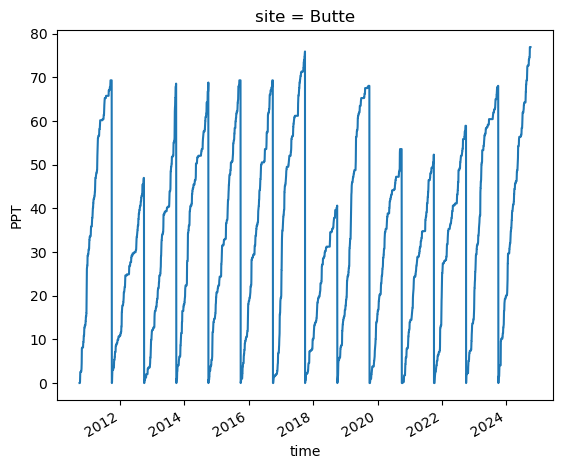

In [ ]:
# ----
# Get column names for SWE and accumulated precip data at each site
SWEcol = df.columns[[1]]
PPTcol = df.columns[[2]]
sites = ['Butte']

# generate individual data frames for observations
SWE = df[SWEcol].set_index(pd.to_datetime(df['Date']))
PPT = df[PPTcol].set_index(pd.to_datetime(df['Date']))

# Now convert to xarray datasets
SWE = SWE.melt(value_vars=SWEcol, value_name='SWE', ignore_index=False) \
       .set_index('variable', append=True) \
       .to_xarray().rename({'Date': 'time','variable': 'site'}) \
       .assign_coords({"site": sites})
SWE = SWE * 2.54 #convert in to cm
PPT = PPT.melt(value_vars=PPTcol, value_name='PPT', ignore_index=False) \
       .set_index('variable', append=True) \
       .to_xarray().rename({'Date': 'time','variable': 'site'}) \
       .assign_coords({"site": sites})
PPT = PPT * 2.54 #convert to cm
OBS = xr.merge([SWE,PPT])
OBS.PPT.isel(site=0).plot();

aspen_sp52.028_PPT1.25_b_Sturm_2org cumPPT 73.91127
aspen_sp52.028_obsSW_PPT1.25_b_Sturm_2org cumPPT 73.91127
aspen_sp52.028_PPT1.25_b_Sturm_2org SNOW_DEPTH 1.1202767
aspen_sp52.028_obsSW_PPT1.25_b_Sturm_2org SNOW_DEPTH 0.98685634


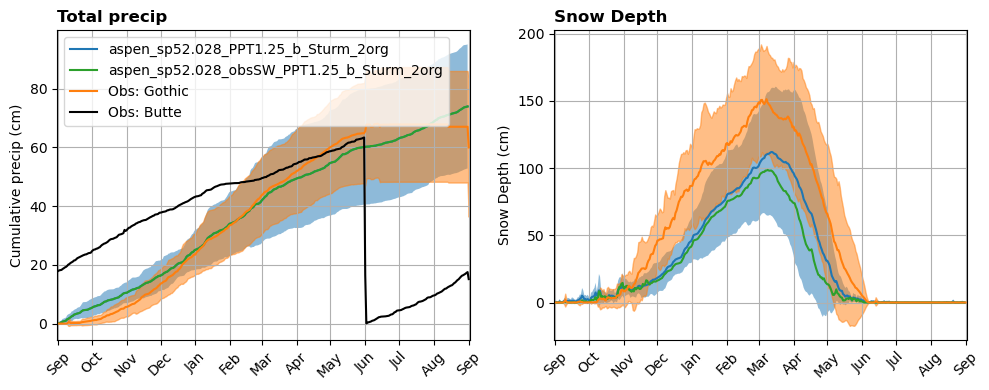

In [ ]:
# calculate observed climatology by water year
Y1 = obs.groupby(obs.day_of_wateryear).mean()
Y1b = obs.groupby(obs.day_of_wateryear).std()

# can't compare obs and model snowfall, as the later is in mm of water
clm_var = ['cumPPT','SNOW_DEPTH','cumSNOW']
obs_var = ['sum.water.cm', 'snow.on.ground.cm','total.snow.cm']
sno_var = ['SWE', 'snow.on.ground.cm','total.snow.cm']
ylabel = ['Cumulative precip (cm)', 'Snow Depth (cm)', 'Cumulative snow (cm)']
title = ['Total precip', 'Snow Depth', 'Total snow']

fig, axes = plt.subplots(1, 2, figsize=(10,4))

for i in range(2):
    Y2 = ds1WY[clm_var[i]].groupby('time.dayofyear').mean().isel(lndgrid=0)
    Y2b = ds1WY[clm_var[i]].groupby('time.dayofyear').std().isel(lndgrid=0)
    print(exp[0]+' '+clm_var[i]+' '+str(Y2.max().values))
    Z2 = ds2WY[clm_var[i]].groupby('time.dayofyear').mean().isel(lndgrid=0)
    Z2b = ds2WY[clm_var[i]].groupby('time.dayofyear').std().isel(lndgrid=0)
    print(exp[1]+' '+clm_var[i]+' '+str(Z2.max().values))
    Z3 = OBS.PPT.isel(site=0).groupby('time.dayofyear').mean()
    if (clm_var[i] == 'SNOW_DEPTH'):
        Y2 = Y2*100 # convert to cm
        Y2b = Y2b*100 # convert to cm
        Z2 = Z2*100 # convert to cm
        Z2b = Z2b*100 # convert to cm

    axes[i].plot(x2, Y2, label = exp[0])
    axes[i].fill_between(x2, Y2-Y2b, Y2+Y2b, alpha=0.5)
    axes[i].plot(x2,Z2,label=exp[1], color='tab:green',linestyle="-")
    #axes[i].fill_between(x2, Z2-Z2b, Z2+Z2b, alpha=0.5)
    axes[i].set_xticks(tick_wy, month_wy[0], rotation=45)
    axes[i].set_xlim(-1,366)
    
    axes[i].plot(x1,Y1[obs_var[i]],label='Obs: Gothic',color='tab:orange')
    axes[i].fill_between(x1, Y1[obs_var[i]] - Y1b[obs_var[i]],
                         Y1[obs_var[i]] + Y1b[obs_var[i]],
                         alpha=0.5,color='tab:orange')

    axes[i].set_ylabel(ylabel[i])
    axes[i].set_title(title[i], loc='left', fontsize='large', fontweight='bold')
    if i == 0: 
        axes[i].plot(x1,Z3,label='Obs: Butte',color='k')
        axes[i].legend()
    axes[i].grid() ;

fig.tight_layout()

#### Total precip OK? 
- Peak snow depth too low in CLM, maybe SWE OK?
- Snow persists too long in CLM?

---
#### Deeper look at model output

NameError: name 'dsWY' is not defined

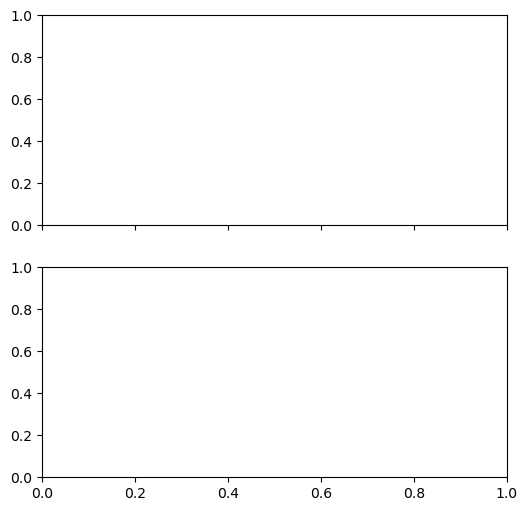

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(6,6), sharex=True)
var = ['SNOW_DEPTH','TSOI']

yrange = range(0,15)
for v in range(0,2):
    for i in yrange:
        t0 = i*365
        t1 = (i+1)*365
        y = dsWY[var[v]].isel(time=slice(t0,t1)).isel(lndgrid=0)
        z = dsWY_noLW[var[v]].isel(time=slice(t0,t1)).isel(lndgrid=0)
        if v == 1:
            y = y.isel(levgrnd=2) 
            z = z.isel(levgrnd=2) 
        x = range(0,365)
        axes[v].plot(x,y,lw=0.4,color='tab:blue')#label=str(year_wy[i]))
        axes[v].plot(x,z,lw=0.4,color='tab:green')#label=str(year_wy[i]))

    y = dsWY[var[v]].groupby('time.dayofyear').mean().isel(lndgrid=0)
    y2 = dsWY[var[v]].groupby('time.dayofyear').std().isel(lndgrid=0)
    z = dsWY_noLW[var[v]].groupby('time.dayofyear').mean().isel(lndgrid=0)
    z2 = dsWY_noLW[var[v]].groupby('time.dayofyear').std().isel(lndgrid=0)
    if v == 1:
        y = y.isel(levgrnd=2) 
        y2 = y2.isel(levgrnd=2) 
        z = z.isel(levgrnd=2) 
        z2 = z2.isel(levgrnd=2) 

    axes[v].plot(x,y,lw=2.4,color='tab:blue')
    #axes[v].fill_between(x, y-y2, y+y2, alpha=0.5,color='tab:blue')
    axes[v].plot(x,z,lw=2.4,color='tab:green')
    #axes[v].fill_between(x, z-z2, z+z2, alpha=0.5,color='tab:green' )
    axes[v].set_xticks(tick_wy, month_wy[0], rotation=45)
    if v == 0:
        axes[v].set_ylabel('Snow Depth (m)')
    else:
        axes[v].set_ylabel('Soil Temperature, 10cm (C)')
    axes[v].set_xlim(-1,366)
    axes[v].hlines(0,-10,365,color='k',lw=2,linestyles='dashed');
    axes[v].grid()
    axes[v].legend(exp)
fig.tight_layout()
#plt.subplots_adjust(wspace=0, hspace=1) ;

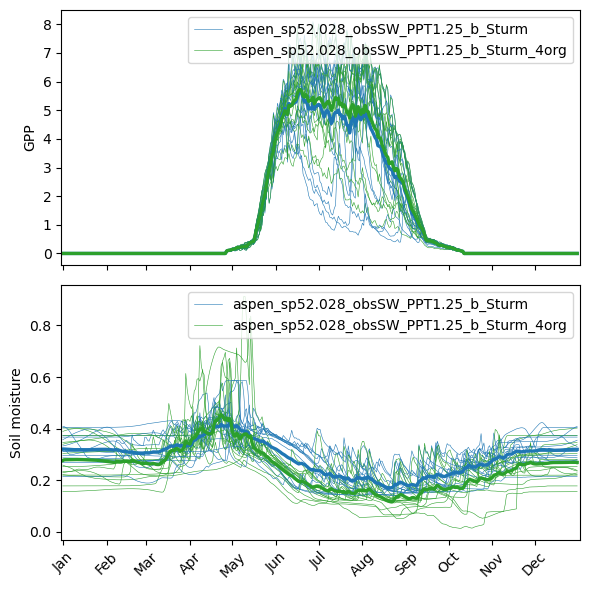

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(6,6), sharex=True)
if SP == True:
    var = ['FPSN','H2OSOI']
else :
    var = ['GPP','H2OSOI']
    
#yrange = range(9,19)
for v in range(0,2):
    for i in yrange:
        t0 = i*365
        t1 = (i+1)*365
        y = ds[var[v]].isel(time=slice(t0,t1)).isel(lndgrid=0)
        z = ds_noLW[var[v]].isel(time=slice(t0,t1)).isel(lndgrid=0)
        if v == 1:
            y = y.isel(levsoi=2) 
            z = z.isel(levsoi=2) 
        x = range(0,365)
        axes[v].plot(x,y,lw=0.4,color='tab:blue')#label=str(year_wy[i]))
        axes[v].plot(x,z,lw=0.4,color='tab:green')#label=str(year_wy[i]))

    y = ds[var[v]].groupby('time.dayofyear').mean().isel(lndgrid=0)
    #y2 = ds[var[v]].groupby('time.dayofyear').std().isel(lndgrid=0)
    z = ds_noLW[var[v]].groupby('time.dayofyear').mean().isel(lndgrid=0)
    #z2 = ds_noLW[var[v]].groupby('time.dayofyear').std().isel(lndgrid=0)
    if v == 1:
        y = y.isel(levsoi=2) 
        #y2 = y2.isel(levsoi=2) 
        z = z.isel(levsoi=2) 
        #z2 = z2.isel(levsoi=2) 

    axes[v].plot(x,y,lw=2.4,color='tab:blue')
    #axes[v].fill_between(x, y-y2, y+y2,color='tab:blue', alpha=0.5)
    axes[v].plot(x,z,lw=2.4,color='tab:green')
    #axes[v].fill_between(x, z-z2, z+z2,color='tab:green', alpha=0.5)
    axes[v].set_xticks(tick, month[0], rotation=45)
    if v == 0:
        axes[v].set_ylabel('GPP')
    else:
        axes[v].set_ylabel('Soil moisture')
    axes[v].set_xlim(-1,366)
    axes[v].legend(exp)

fig.tight_layout()
#plt.subplots_adjust(wspace=0, hspace=1) ;

### How is interannual variability:
- Look at invidual years
- NOTE, this code is likely broken since we're reading now in H1 files in 1050 (from 1000 start)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


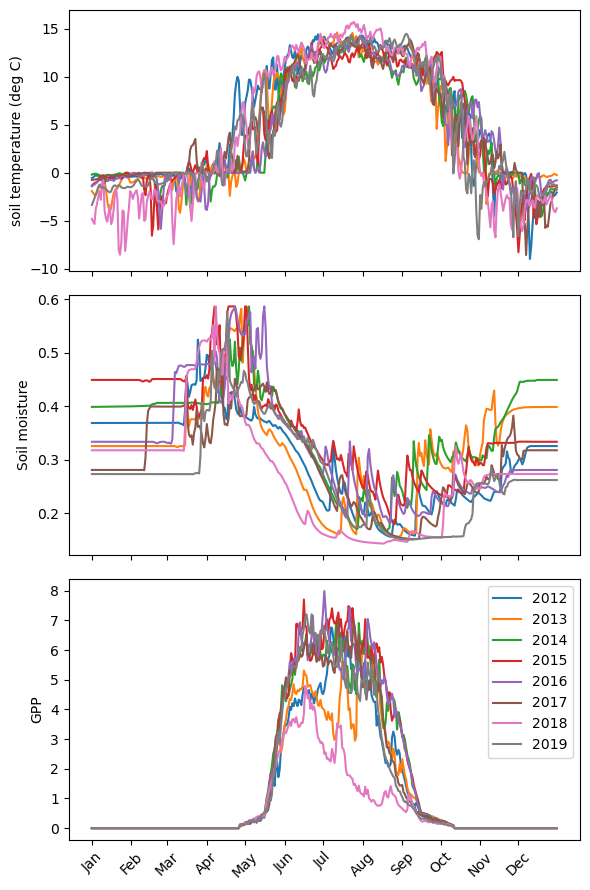

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(6,9), sharex=True)
    
yrange = range(12,20)
for v in range(3):
    for i in yrange:
        t0 = i*365
        t1 = (i+1)*365
        if v == 0:
            y = ds.TSOI.isel(time=slice(t0,t1),levgrnd=2)
        if v == 1:
            y = ds.H2OSOI.isel(time=slice(t0,t1),levsoi=2)
        if v == 2:
            y = ds.FPSN.isel(time=slice(t0,t1))
            
        x = range(0,365)
        axes[v].plot(x,y,label=str(year[i]))
        axes[v].set_xticks(tick, month[0], rotation=45)
        
    axes[0].set_ylabel('soil temperature (deg C)')
    axes[1].set_ylabel('Soil moisture')
    axes[2].set_ylabel('GPP')
    plt.legend() ;

fig.tight_layout()


#### Driest years = 2012, 2013, 2018

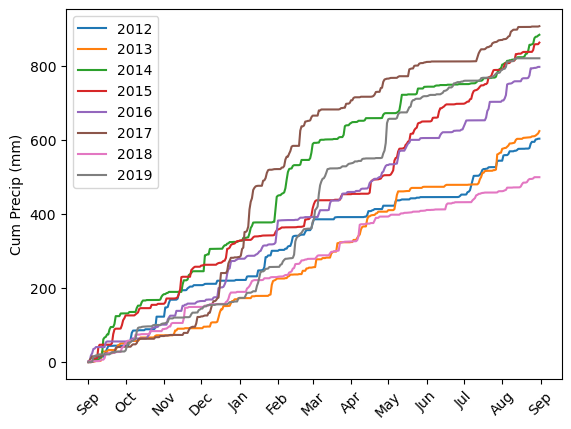

In [ ]:
yrange = range(0,19)
spd = 3600*24
dsWY['PRECIP'] = (dsWY.SNOW + dsWY.RAIN)
WATERYEAR = np.empty(19)
RAIN = np.empty(19)
SNOW = np.empty(19)
for i in yrange:
    t0 = i*365
    t1 = (i+1)*365
    y = dsWY.PRECIP.isel(time=slice(t0,t1)).cumsum()*spd
    WATERYEAR[i] = int(year_wy[i])
    SNOW[i] = ((dsWY.SNOW.isel(time=slice(t0,t1)).cumsum()*spd).max().values)
    RAIN[i] = ((dsWY.RAIN.isel(time=slice(t0,t1)).cumsum()*spd).max().values)
    x = range(0,365)
    if i>10:
        plt.plot(x,y,label=str(year_wy[i]))
    
plt.xticks(tick_wy, month_wy[0], rotation=45)
plt.ylabel('Cum Precip (mm)')
plt.legend() ;

TOTAL = RAIN+SNOW

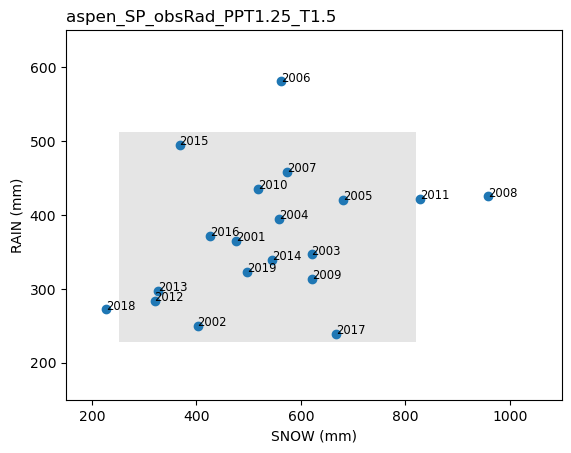

In [ ]:
meanSNOW = SNOW.mean()
stdSNOW = SNOW.std()*1.644
meanRAIN = RAIN.mean()
stdRAIN = RAIN.std()*1.644

left, bottom, width, height = ((meanSNOW-stdSNOW), (meanRAIN-stdRAIN), 
                               (2*stdSNOW), (2*stdRAIN))
rect = plt.Rectangle((left, bottom), width, height,
                     facecolor="black", alpha=0.1)

fig, ax = plt.subplots()
ax.add_patch(rect)
ax.scatter(SNOW,RAIN)

for i, txt in enumerate(WATERYEAR.astype(int)):
    ax.annotate(txt, (SNOW[i],RAIN[i]), fontsize='small')
plt.xlabel('SNOW (mm)')
plt.ylabel('RAIN (mm)')
plt.xlim(150,1100)
plt.ylim(150,650)
plt.title(exp[0], loc='left')
plt.show()

#### How does this compare with [Mariah's 2023 paper](https://iopscience.iop.org/article/10.1088/1748-9326/ad07b5/meta)?

----

#### Look a depth profiles of soil moisture
- likely need to adjust soil depth and properties for sites?

In [ ]:
ds.isel(time=slice((18*365),(19*365))).time

<xarray.DataArray 'time' (time: 365)>
array([cftime.DatetimeNoLeap(1038, 1, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1038, 1, 2, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1038, 1, 3, 0, 0, 0, 0, has_year_zero=True), ...,
       cftime.DatetimeNoLeap(1038, 12, 29, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1038, 12, 30, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1038, 12, 31, 0, 0, 0, 0, has_year_zero=True)],
      dtype=object)
Coordinates:
  * time     (time) object 1038-01-01 00:00:00 ... 1038-12-31 00:00:00

In [ ]:
ds.time

<xarray.DataArray 'time' (time: 7300)>
array([cftime.DatetimeNoLeap(1020, 1, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1020, 1, 2, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1020, 1, 3, 0, 0, 0, 0, has_year_zero=True), ...,
       cftime.DatetimeNoLeap(1039, 12, 29, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1039, 12, 30, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1039, 12, 31, 0, 0, 0, 0, has_year_zero=True)],
      dtype=object)
Coordinates:
  * time     (time) object 1020-01-01 00:00:00 ... 1039-12-31 00:00:00

In [ ]:
ds.levsoi.attrs = []
ds.H2OSOI.attrs['long_name'] = 'volumetric soil water'

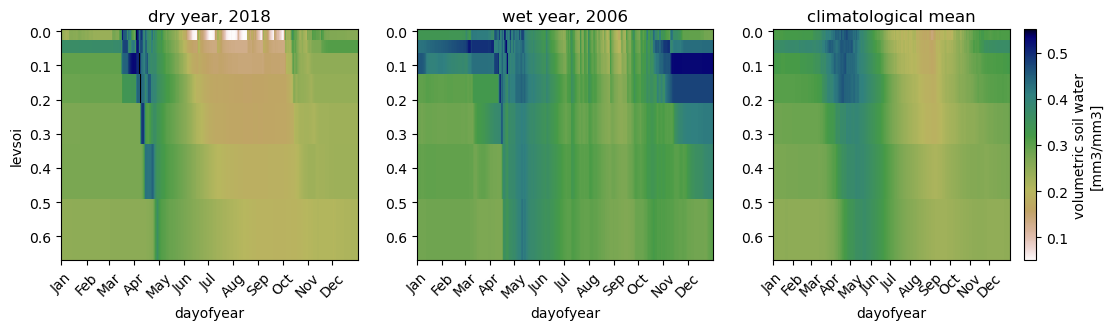

In [ ]:
plt.figure(figsize=[13,3])
plt.subplot(1, 3, 1)
#ds.H2OSOI.groupby('time.dayofyear').min().isel(
ds.H2OSOI.isel(time=slice((18*365),(19*365))).groupby('time.dayofyear').mean().isel(
    lndgrid=0,levsoi=slice(0,7)).plot(
    x='dayofyear',robust=True,vmin=0.05,vmax=0.55,cmap='gist_earth_r',add_colorbar=False)
plt.gca().invert_yaxis() ;
plt.xticks(tick, month[0], rotation=45) ;
plt.title('dry year, 2018')

plt.subplot(1, 3, 2)
ds.H2OSOI.isel(time=slice((6*365),(7*365))).groupby('time.dayofyear').mean().isel(
    lndgrid=0,levsoi=slice(0,7)).plot(
    x='dayofyear',robust=True,vmin=0.05,vmax=0.55,cmap='gist_earth_r',add_colorbar=False)
plt.gca().invert_yaxis() ;
plt.xticks(tick, month[0], rotation=45) ;
plt.title('wet year, 2006')
plt.ylabel(None)

plt.subplot(1, 3, 3)
ds.H2OSOI.groupby('time.dayofyear').mean().isel(
    lndgrid=0,levsoi=slice(0,7)).plot(
    x='dayofyear',vmin=0.05,vmax=0.55,cmap='gist_earth_r',add_colorbar=True)
plt.gca().invert_yaxis() ;
plt.xticks(tick, month[0], rotation=45) ;
plt.title('climatological mean')
plt.ylabel(None)

#ds.H2OSOI.groupby('time.dayofyear').max().isel(
#    lndgrid=0,levsoi=slice(0,9)).plot(
#    x='dayofyear',robust=True,vmin=0.0,vmax=0.6,cmap='gist_earth_r')
#plt.gca().invert_yaxis() ;
#plt.xticks(tick, month[0], rotation=45) ;
#plt.title('max')

fig.tight_layout()


In [ ]:
ds.TSOI


<xarray.DataArray 'TSOI' (time: 7300, levgrnd: 25, lndgrid: 1)>
dask.array<transpose, shape=(7300, 25, 1), dtype=float32, chunksize=(3650, 25, 1), chunktype=numpy.ndarray>
Coordinates:
  * levgrnd  (levgrnd) float32 0.01 0.04 0.09 0.16 ... 13.33 19.48 28.87 42.0
  * time     (time) object 1020-01-01 00:00:00 ... 1039-12-31 00:00:00
Dimensions without coordinates: lndgrid
Attributes:
    units:    degC

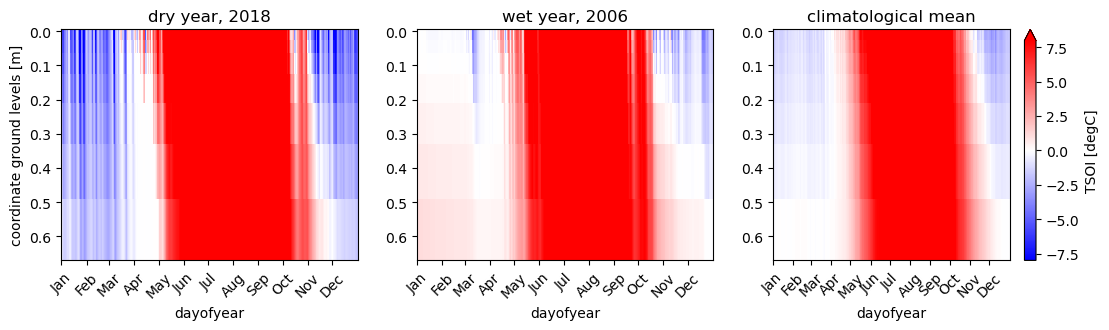

In [ ]:
VMIN, VMAX = -8,8
plt.figure(figsize=[13,3])
plt.subplot(1, 3, 1)
#ds.H2OSOI.groupby('time.dayofyear').min().isel(
ds.TSOI.isel(time=slice((18*365),(19*365))).groupby('time.dayofyear').mean().isel(
    lndgrid=0,levgrnd=slice(0,7)).plot(
    x='dayofyear',vmin=VMIN,vmax=VMAX,cmap='bwr',add_colorbar=False)
plt.gca().invert_yaxis() ;
plt.xticks(tick, month[0], rotation=45) ;
plt.title('dry year, 2018')

plt.subplot(1, 3, 2)
ds.TSOI.isel(time=slice((6*365),(7*365))).groupby('time.dayofyear').mean().isel(
    lndgrid=0,levgrnd=slice(0,7)).plot(
    x='dayofyear',vmin=VMIN,vmax=VMAX,cmap='bwr',add_colorbar=False)
plt.gca().invert_yaxis() ;
plt.xticks(tick, month[0], rotation=45) ;
plt.title('wet year, 2006')
plt.ylabel(None)

plt.subplot(1, 3, 3)
ds.TSOI.groupby('time.dayofyear').mean().isel(
    lndgrid=0,levgrnd=slice(0,7)).plot(
    x='dayofyear',vmin=VMIN,vmax=VMAX,cmap='bwr',add_colorbar=True)
plt.gca().invert_yaxis() ;
plt.xticks(tick, month[0], rotation=45) ;
plt.title('climatological mean')
plt.ylabel(None)

fig.tight_layout()


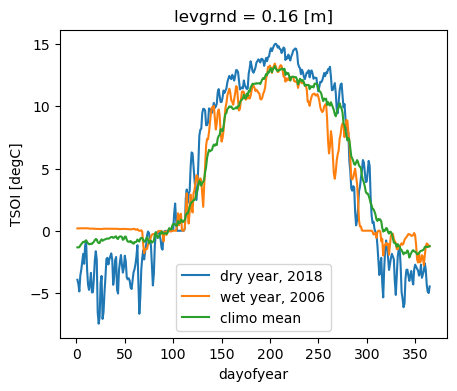

In [ ]:
plt.figure(figsize=[5,4])
#ds.H2OSOI.groupby('time.dayofyear').min().isel(
ds.TSOI.isel(time=slice((18*365),(19*365))).groupby('time.dayofyear').mean().isel(
    lndgrid=0,levgrnd=slice(3,4)).plot(
    x='dayofyear', label='dry year, 2018')

ds.TSOI.isel(time=slice((6*365),(7*365))).groupby('time.dayofyear').mean().isel(
    lndgrid=0,levgrnd=slice(3,4)).plot(
    x='dayofyear', label='wet year, 2006')

ds.TSOI.groupby('time.dayofyear').mean().isel(
    lndgrid=0,levgrnd=slice(3,4)).plot(
    x='dayofyear',label='climo mean') 
plt.legend() ;

Text(0.5, 0, '')

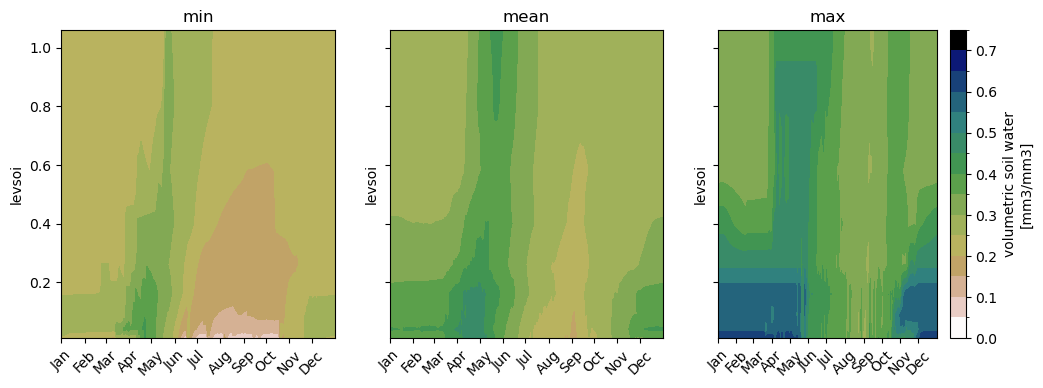

In [ ]:
fig, axs = plt.subplots(ncols=3, nrows=1,
                        figsize=(12,4),
                        sharey=True)
[ax1, ax2, ax3] = axs

vmin=0.05
vmax=0.75
levels=[0,  0.05,0.1,0.15,0.2,0.25,0.3,0.35,
        0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75]
cmap='gist_earth_r'

a = ds.H2OSOI.groupby('time.dayofyear').min().isel(
    lndgrid=0,levsoi=slice(0,9)).plot.contourf(ax=ax1,  x='dayofyear',levels=levels,
                                               vmin=vmin,vmax=vmax,cmap=cmap,add_colorbar = False)
ax1.set_xticks(tick, month[0], rotation=45) ;
ax1.set_title('min')
ax1.set_xlabel(None)

a = ds.H2OSOI.groupby('time.dayofyear').mean().isel(
    lndgrid=0,levsoi=slice(0,9)).plot.contourf(ax=ax2,  x='dayofyear',levels=levels,
                                               vmin=vmin,vmax=vmax,cmap=cmap,add_colorbar = False)
ax2.set_xticks(tick, month[0], rotation=45) ;
ax2.set_title('mean') ;
ax2.set_xlabel(None)

a = ds.H2OSOI.groupby('time.dayofyear').max().isel(
    lndgrid=0,levsoi=slice(0,9)).plot.contourf(ax=ax3,  x='dayofyear',levels=levels,
                                               vmin=vmin,vmax=vmax,cmap=cmap,add_colorbar = True)
ax3.set_xticks(tick, month[0], rotation=45) ;
ax3.set_title('max') ;
ax3.set_xlabel(None)

In [ ]:
a = ds.H2OSOI.sel(time=ds.time.dt.year.isin([2012])).isel(
    lndgrid=0,levsoi=slice(0,9)).plot.contourf(ax=ax4,  x='time',levels=levels,
                                               vmin=vmin,vmax=vmax,cmap=cmap,add_colorbar = False)
ax4.set_title('2012, low snow + OK summer') ;

a = ds.H2OSOI.sel(time=ds.time.dt.year.isin([2013])).isel(
    lndgrid=0,levsoi=slice(0,9)).plot.contourf(ax=ax5,  x='time',levels=levels,
                                               vmin=vmin,vmax=vmax,cmap=cmap,add_colorbar = False)
ax5.set_title('2013, low snow, 2nd year drought') ;

a = ds.H2OSOI.sel(time=ds.time.dt.year.isin([2017])).isel(
    lndgrid=0,levsoi=slice(0,9)).plot.contourf(ax=ax6,  x='time',levels=levels,
                                               vmin=vmin,vmax=vmax,cmap=cmap,add_colorbar = False)
ax6.set_title('2017, high snow + dry summer') ;

plt.gca().invert_yaxis() ;
fig.subplots_adjust(right=.92) #also try using kwargs bottom, top, or hspace 
cbar_ax = fig.add_axes([0.95, 0.1, .02, .75]) #left, bottom, width, height
fig.colorbar(a, cax=cbar_ax, orientation="vertical", 
             label=ds.H2OSOI.attrs['long_name']+" ("+ds.H2OSOI.attrs['units']+")") ;

NameError: name 'ax4' is not defined